#VAR-Modell – Multivariate Zeitreihenanalyse

##Luftdruck · Windgeschwindigkeit · Temperatur (Würzburg, Station 5705)

Datenquelle: data/originals&cleaned/ – je eine bereinigte CSV pro Variable
Methode: Vector Autoregression (VAR)

Analyse-Schritte:

  0. Daten laden & zusammenführen
  1. Explorative Analyse (Plots, Korrelation)
  2. Stationaritätstests (ADF, KPSS) je Variable
  3. Transformation zur Stationarität
  4. Lag-Selektion (AIC, BIC, HQIC)
  5. Modellschätzung & Zusammenfassung
  6. Residuendiagnose (Whiteness, Normalität)
  7. Granger-Kausalität
  8. Impuls-Antwort-Analyse (IRF) & Varianzdekomposition (FEVD)
  9. Train/Val/Test-Split (70/15/15) & Evaluation
  10. Time-Series-Cross-Validation (5-Fold)
  11. 10-Tage-Prognose
  12. Holdout-Evaluation

In [1]:
# Nur fuer Google Colab benoetigt – lokal nicht ausfuehren
# import os
# os.system("rm -rf Menden_S26_clean")
# os.system("git clone https://github.com/cladensk334/Menden_S26_clean.git")

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from scipy import stats

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

def _repo_root() -> Path:
    p = Path().resolve()
    for folder in [p, *p.parents]:
        if (folder / '.git').is_dir():
            return folder
    return p

ROOT       = _repo_root()
PLOTORDNER = str(ROOT / "Plots")
os.makedirs(PLOTORDNER, exist_ok=True)
print(f"Repo-Root  : {ROOT}")
print(f"Plotordner : {PLOTORDNER}")

Repo-Root  : C:\Users\Susi_\Menden_S26_clean
Plotordner : C:\Users\Susi_\Menden_S26_clean\Plots


#0. DATEN LADEN UND ZUSAMMENFÜHREN

In [19]:
DIR = ROOT / 'data' / 'originals&cleaned'

def lade_csv(dateiname: str, spalte: str) -> pd.Series:
    s = (pd.read_csv(DIR / dateiname, parse_dates=['datum'], index_col='datum')
           .squeeze().asfreq('D'))
    s.name = spalte
    return s

ts_luft = lade_csv('luftdruck_bereinigt.csv',  'luftdruck_hpa')
ts_wind = lade_csv('wind_bereinigt.csv',        'windgeschwindigkeit_ms')
ts_temp = lade_csv('temperatur_bereinigt.csv',  'temperatur_mittel_c')

df = pd.concat([ts_luft, ts_wind, ts_temp], axis=1).dropna()

# Holdout
df_holdout = df.iloc[-10:]
df         = df.iloc[:-10]

VARIABLEN = list(df.columns)

print(f'Variablen     : {VARIABLEN}')
print(f'Analyse-Reihe : {df.index[0].date()} bis {df.index[-1].date()}  ({len(df):,} Tage)')
print(f'Holdout       : {df_holdout.index[0].date()} bis {df_holdout.index[-1].date()}  (10 Tage)')
print()
print(df.describe().round(2))

Variablen     : ['luftdruck_hpa', 'windgeschwindigkeit_ms', 'temperatur_mittel_c']
Analyse-Reihe : 1966-01-01 bis 2026-01-01  (21,916 Tage)
Holdout       : 2026-01-02 bis 2026-01-11  (10 Tage)

       luftdruck_hpa  windgeschwindigkeit_ms  temperatur_mittel_c
count       21916.00                21916.00             21916.00
mean          984.60                    3.10                 9.86
std             8.21                    1.73                 7.66
min           938.70                    0.00               -18.20
25%           979.80                    1.90                 3.90
50%           985.00                    2.70                10.00
75%           989.90                    3.90                15.90
max          1012.30                   14.90                30.30


#1. EXPLORATIVE ANALYSE

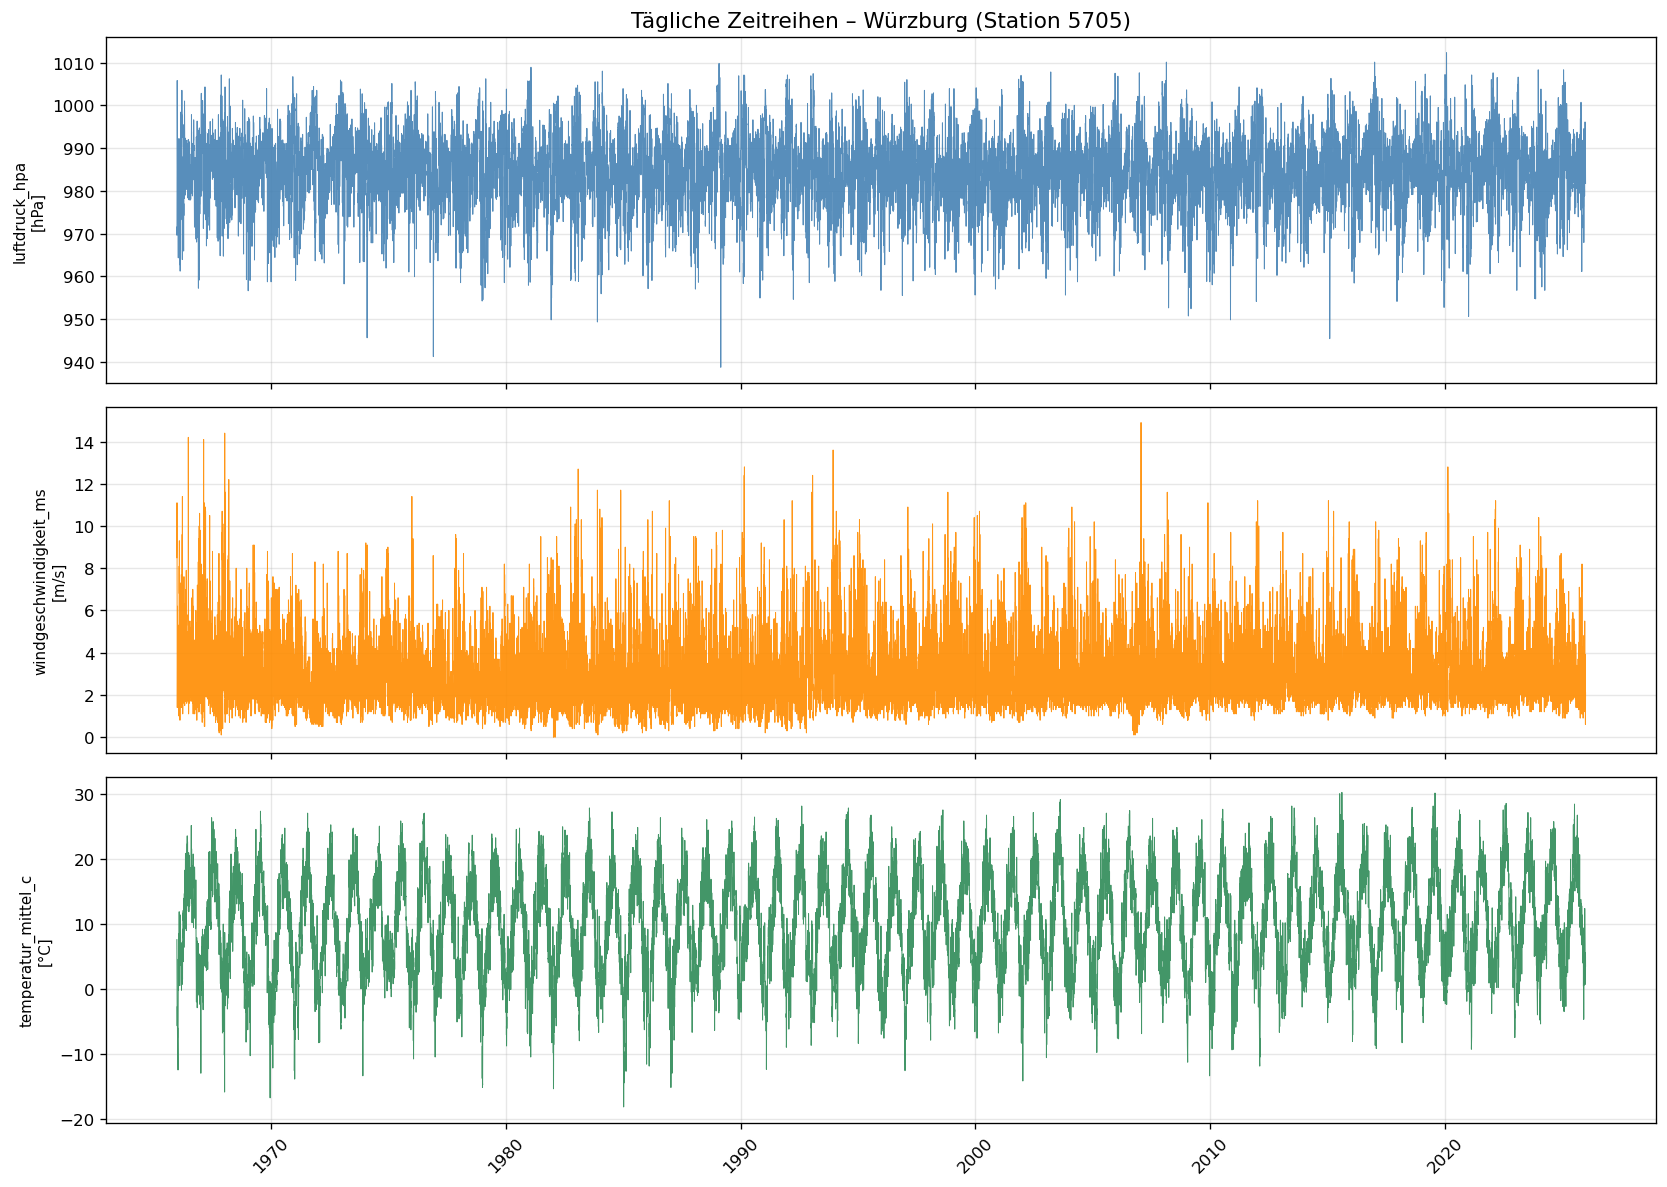


Korrelationsmatrix (Pearson):
                        luftdruck_hpa  windgeschwindigkeit_ms  \
luftdruck_hpa                   1.000                  -0.334   
windgeschwindigkeit_ms         -0.334                   1.000   
temperatur_mittel_c            -0.043                  -0.128   

                        temperatur_mittel_c  
luftdruck_hpa                        -0.043  
windgeschwindigkeit_ms               -0.128  
temperatur_mittel_c                   1.000  


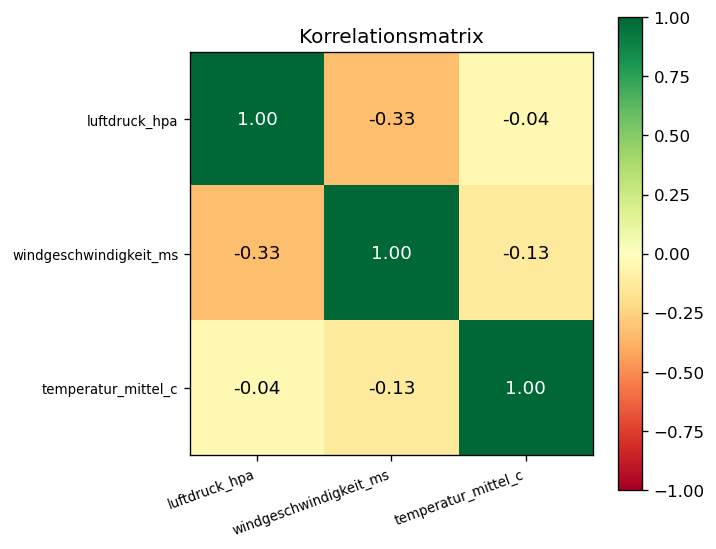

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
farben    = ['steelblue', 'darkorange', 'seagreen']
einheiten = ['hPa', 'm/s', '°C']

for ax, col, farbe, einheit in zip(axes, VARIABLEN, farben, einheiten):
    ax.plot(df.index, df[col], lw=0.6, color=farbe, alpha=0.9)
    ax.set_ylabel(f'{col}\n[{einheit}]', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Tägliche Zeitreihen – Würzburg (Station 5705)', fontsize=13)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(10))
axes[-1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_01_zeitreihen.png'), bbox_inches='tight')
plt.show()

# Korrelationsmatrix
print('\nKorrelationsmatrix (Pearson):')
corr = df.corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(VARIABLEN)))
ax.set_xticklabels(VARIABLEN, rotation=20, ha='right', fontsize=8)
ax.set_yticks(range(len(VARIABLEN)))
ax.set_yticklabels(VARIABLEN, fontsize=8)
for i in range(len(VARIABLEN)):
    for j in range(len(VARIABLEN)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=11, color='black' if abs(corr.iloc[i,j]) < 0.7 else 'white')
plt.colorbar(im, ax=ax)
ax.set_title('Korrelationsmatrix', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_02_korrelation.png'), bbox_inches='tight')
plt.show()


#2. STATIONARITÄTSTESTS (ADF & KPSS)

In [5]:
print('=' * 70)
print('STATIONARITÄTSTESTS  (5%-Niveau)')
print('=' * 70)

def adf_test(serie, name):
    r = adfuller(serie.dropna(), autolag='AIC')
    ok = r[1] < 0.05
    print(f'  ADF  {name:<30}  p={r[1]:.4f}  =>  {"STATIONAER" if ok else "NICHT STATIONAER"}')
    return ok

def kpss_test(serie, name):
    r = kpss(serie.dropna(), regression='c', nlags='auto')
    ok = r[1] >= 0.05
    print(f'  KPSS {name:<30}  p={r[1]:.4f}  =>  {"STATIONAER" if ok else "NICHT STATIONAER"}')
    return ok

stationaer_niveau = {}
print('\n--- Niveau ---')
for col in VARIABLEN:
    a = adf_test(df[col], col)
    k = kpss_test(df[col], col)
    stationaer_niveau[col] = (a and k)

stationaer_diff = {}
print('\n--- Erste Differenz ---')
for col in VARIABLEN:
    d1 = df[col].diff().dropna()
    a  = adf_test(d1, col + ' (d=1)')
    k  = kpss_test(d1, col + ' (d=1)')
    stationaer_diff[col] = (a and k)

d_noetig = not all(stationaer_niveau.values())
print(f'\n  => Differenzierung noetig: {d_noetig}')
print(f'     Stationaer im Niveau   : {stationaer_niveau}')

STATIONARITÄTSTESTS  (5%-Niveau)

--- Niveau ---
  ADF  luftdruck_hpa                   p=0.0000  =>  STATIONAER
  KPSS luftdruck_hpa                   p=0.1000  =>  STATIONAER


C:\Users\Susi_\AppData\Local\Temp\ipykernel_95700\2739982794.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(serie.dropna(), regression='c', nlags='auto')


  ADF  windgeschwindigkeit_ms          p=0.0000  =>  STATIONAER
  KPSS windgeschwindigkeit_ms          p=0.0317  =>  NICHT STATIONAER
  ADF  temperatur_mittel_c             p=0.0000  =>  STATIONAER
  KPSS temperatur_mittel_c             p=0.1000  =>  STATIONAER

--- Erste Differenz ---


C:\Users\Susi_\AppData\Local\Temp\ipykernel_95700\2739982794.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(serie.dropna(), regression='c', nlags='auto')


  ADF  luftdruck_hpa (d=1)             p=0.0000  =>  STATIONAER
  KPSS luftdruck_hpa (d=1)             p=0.1000  =>  STATIONAER


C:\Users\Susi_\AppData\Local\Temp\ipykernel_95700\2739982794.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(serie.dropna(), regression='c', nlags='auto')


  ADF  windgeschwindigkeit_ms (d=1)    p=0.0000  =>  STATIONAER
  KPSS windgeschwindigkeit_ms (d=1)    p=0.1000  =>  STATIONAER


C:\Users\Susi_\AppData\Local\Temp\ipykernel_95700\2739982794.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(serie.dropna(), regression='c', nlags='auto')


  ADF  temperatur_mittel_c (d=1)       p=0.0000  =>  STATIONAER
  KPSS temperatur_mittel_c (d=1)       p=0.1000  =>  STATIONAER

  => Differenzierung noetig: True
     Stationaer im Niveau   : {'luftdruck_hpa': True, 'windgeschwindigkeit_ms': False, 'temperatur_mittel_c': True}


C:\Users\Susi_\AppData\Local\Temp\ipykernel_95700\2739982794.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(serie.dropna(), regression='c', nlags='auto')


#3. TRANSFORMATION ZUR STATIONARITÄT

  1-fache Differenzierung angewendet.
  Beobachtungen nach Transformation: 21,904
  Integrationsordnung d = 1


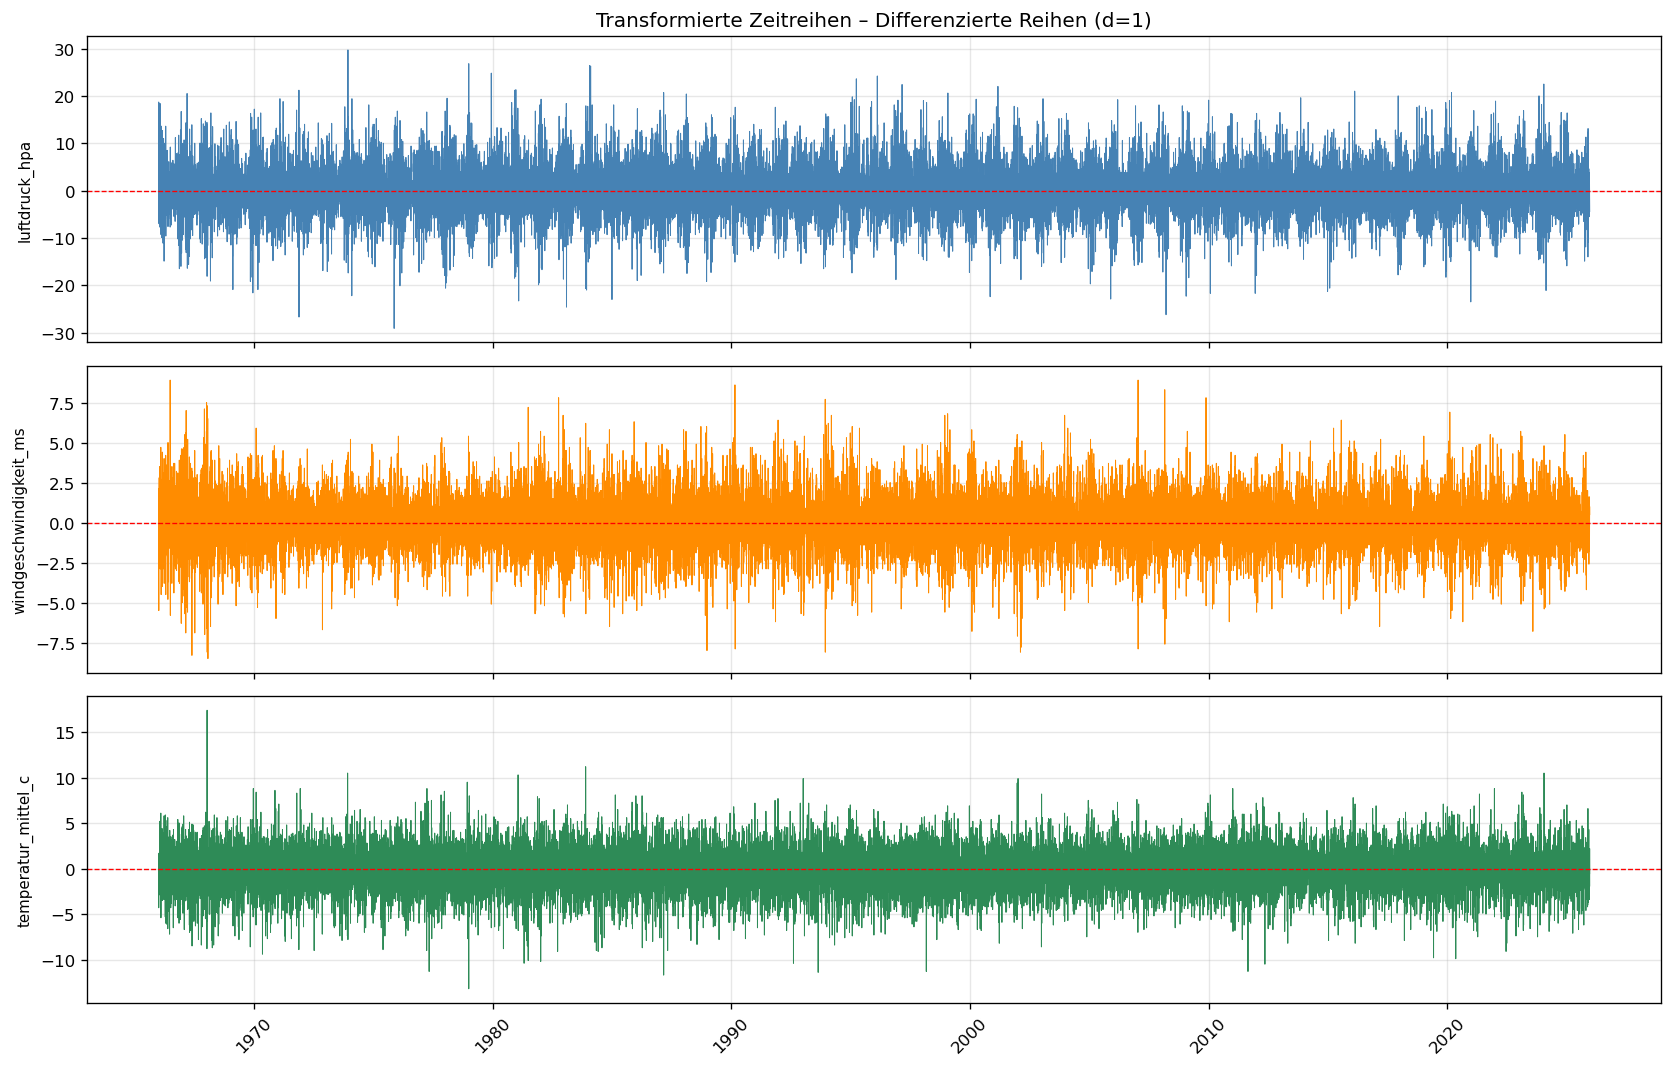

In [6]:

if d_noetig:
    df_stat = df.diff().dropna()
    d_VAR   = 1
    print('  1-fache Differenzierung angewendet.')
else:
    df_stat = df.copy()
    d_VAR   = 0
    print('  Keine Differenzierung noetig – Niveau wird verwendet.')

print(f'  Beobachtungen nach Transformation: {len(df_stat):,}')
print(f'  Integrationsordnung d = {d_VAR}')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
titel  = 'Differenzierte Reihen (d=1)' if d_VAR else 'Niveau-Reihen (d=0)'
farben = ['steelblue', 'darkorange', 'seagreen']

for ax, col, farbe in zip(axes, VARIABLEN, farben):
    ax.plot(df_stat.index, df_stat[col], lw=0.6, color=farbe)
    ax.axhline(0, color='red', ls='--', lw=0.8)
    ax.set_ylabel(col, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title(f'Transformierte Zeitreihen – {titel}', fontsize=12)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(10))
axes[-1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_03_transformation.png'), bbox_inches='tight')
plt.show()


#4. LAG-SELEKTION

In [7]:
print('=' * 70)
print('LAG-SELEKTION – VAR(p)')
print('=' * 70)

modell_var = VAR(df_stat)
lag_auswahl = modell_var.select_order(maxlags=5)
print(lag_auswahl.summary())

p_aic  = int(lag_auswahl.aic)  if int(lag_auswahl.aic)  > 0 else 1
p_bic  = int(lag_auswahl.bic)  if int(lag_auswahl.bic)  > 0 else 1

print(f'  AIC -> p = {p_aic}')
print(f'  BIC -> p = {p_bic}')

# Sparsamster Kandidat (analog zur ARIMA-Modellselektion)
if p_aic == p_bic:
    p_final = p_aic
    grund = 'AIC und BIC einig'
elif p_bic < p_aic:
    p_final = p_bic
    grund = f'BIC sparsamer ({p_bic} Lags) vs. AIC ({p_aic} Lags)'
else:
    p_final = p_aic
    grund = f'AIC sparsamer ({p_aic} Lags) vs. BIC ({p_bic} Lags)'

p_final = max(p_final, 1)
print(f'\n  => Gewaaehltes Modell: VAR({p_final})  [{grund}]')

LAG-SELEKTION – VAR(p)
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       5.701       5.702       299.3       5.702
1       5.578       5.582       264.5       5.579
2       5.446       5.454       231.8       5.448
3       5.389       5.400       218.9       5.392
4       5.351       5.366       210.9       5.356
5      5.323*      5.340*      204.9*      5.328*
-------------------------------------------------
  AIC -> p = 5
  BIC -> p = 5

  => Gewaaehltes Modell: VAR(5)  [AIC und BIC einig]


#5. MODELLSCHÄTZUNG

In [8]:
print('=' * 70)
print(f'VAR({p_final})-MODELL SCHAETZEN')
print('=' * 70)

fit_var = modell_var.fit(p_final)
print(fit_var.summary())


VAR(5)-MODELL SCHAETZEN
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 18, May, 2026
Time:                     09:32:48
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    5.34003
Nobs:                     21899.0    HQIC:                   5.32821
Log likelihood:          -151451.    FPE:                    204.896
AIC:                      5.32250    Det(Omega_mle):         204.448
--------------------------------------------------------------------
Results for equation luftdruck_hpa
                               coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------
const                            -0.000700         0.033056           -0.021           0.983
L1.luftdruck_hpa                  0.140459         0.007213           19.

#6. RESIDUENDIAGNOSE

RESIDUENDIAGNOSE

  Durbin-Watson (Wert nahe 2 = keine Autokorrelation):
    luftdruck_hpa                   : 2.0175
    windgeschwindigkeit_ms          : 2.0281
    temperatur_mittel_c             : 2.0115

  Portmanteau-Test (H0: keine Autokorrelation in Residuen):
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         1915.          61.66   0.000 45
----------------------------------------

  Normalitaetstest (Jarque-Bera):
    luftdruck_hpa                   : JB=3003.97  p=0.0000  => H0 ABGELEHNT
    windgeschwindigkeit_ms          : JB=3845.54  p=0.0000  => H0 ABGELEHNT
    temperatur_mittel_c             : JB=830.78  p=0.0000  => H0 ABGELEHNT


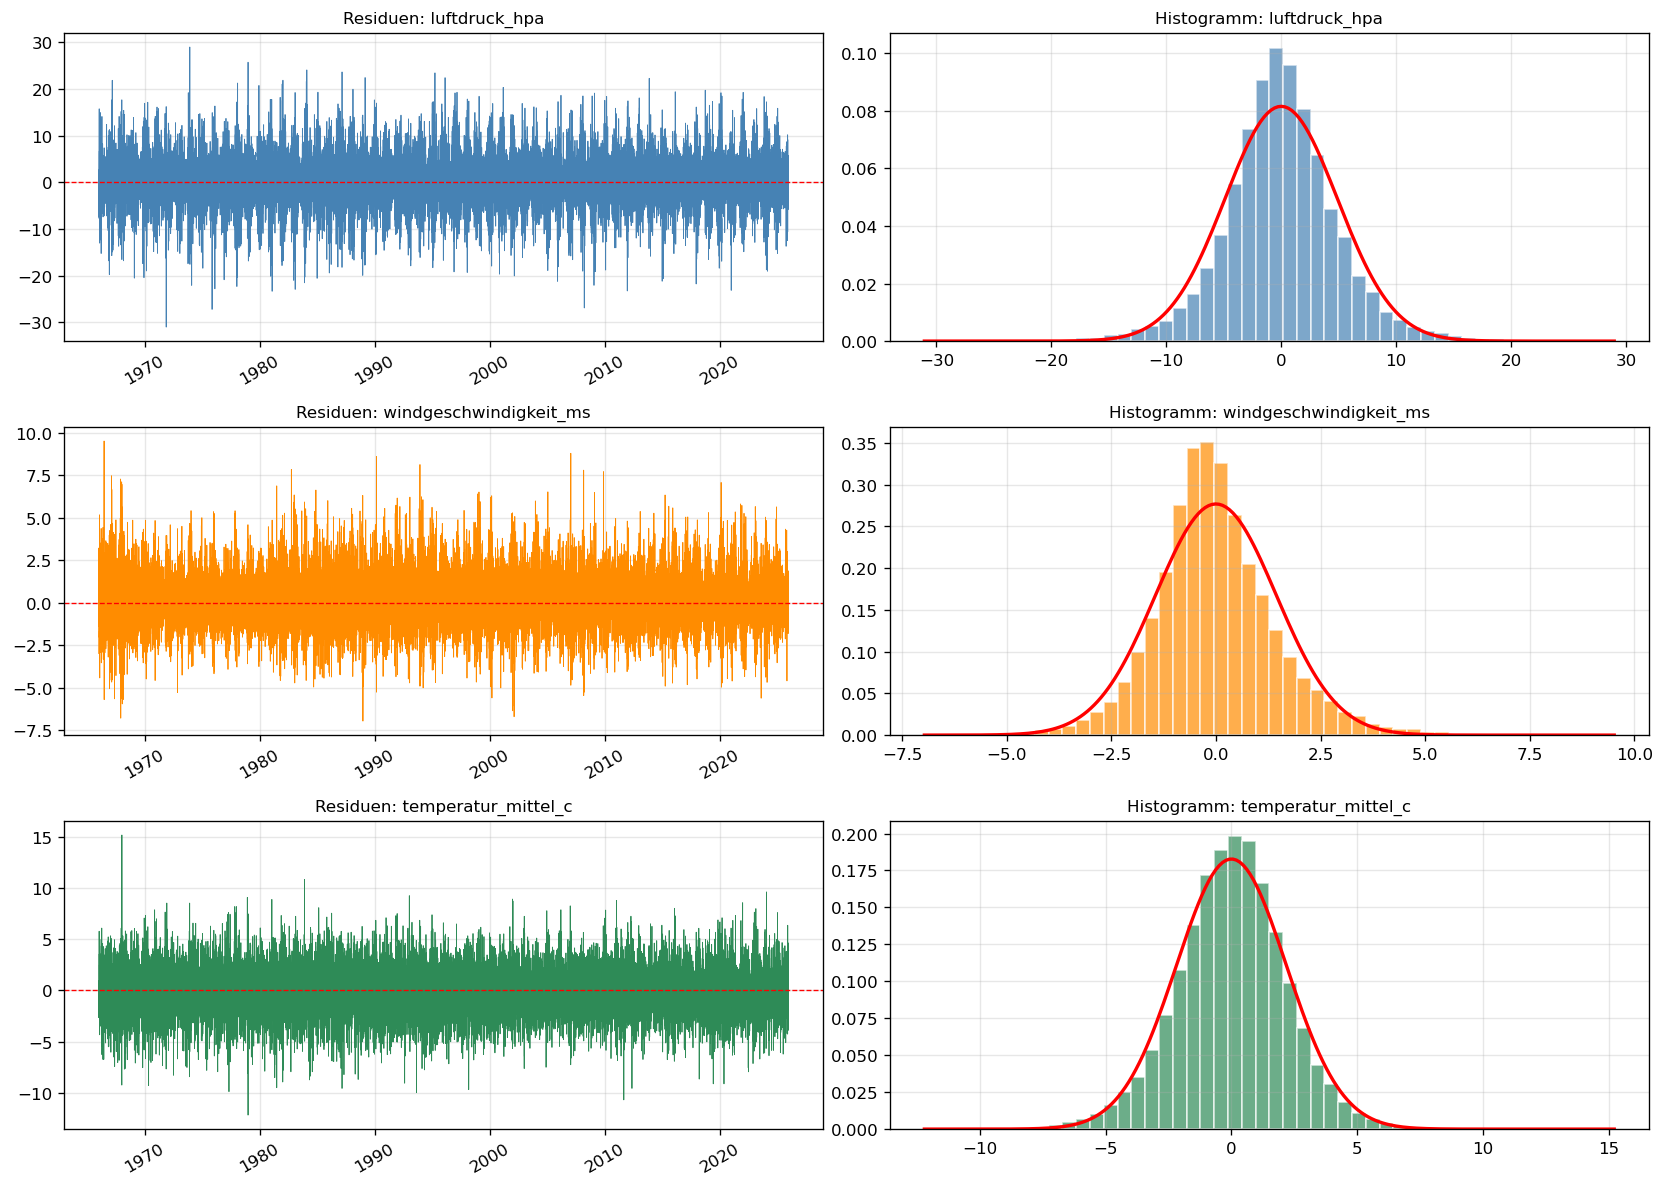

In [9]:
print('=' * 70)
print('RESIDUENDIAGNOSE')
print('=' * 70)

residuen = pd.DataFrame(fit_var.resid, columns=VARIABLEN,
                        index=df_stat.index[p_final:])

print('\n  Durbin-Watson (Wert nahe 2 = keine Autokorrelation):')
for col in VARIABLEN:
    dw = durbin_watson(residuen[col])
    print(f'    {col:<32}: {dw:.4f}')

print('\n  Portmanteau-Test (H0: keine Autokorrelation in Residuen):')
pt = fit_var.test_whiteness(nlags=10, signif=0.05)
print(pt.summary())

print('\n  Normalitaetstest (Jarque-Bera):')
for col in VARIABLEN:
    jb, p_jb = stats.jarque_bera(residuen[col].dropna())
    entscheid = 'nicht abgelehnt' if p_jb > 0.05 else 'ABGELEHNT'
    print(f'    {col:<32}: JB={jb:.2f}  p={p_jb:.4f}  => H0 {entscheid}')

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
farben = ['steelblue', 'darkorange', 'seagreen']

for row, (col, farbe) in enumerate(zip(VARIABLEN, farben)):
    res = residuen[col].dropna()
    axes[row, 0].plot(res.index, res.values, lw=0.5, color=farbe)
    axes[row, 0].axhline(0, color='red', ls='--', lw=0.8)
    axes[row, 0].set_title(f'Residuen: {col}', fontsize=10)
    axes[row, 0].grid(True, alpha=0.3)
    axes[row, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[row, 0].xaxis.set_major_locator(mdates.YearLocator(10))
    axes[row, 0].tick_params(axis='x', rotation=30)
    axes[row, 1].hist(res, bins=50, color=farbe, alpha=0.7, density=True, edgecolor='white')
    x = np.linspace(res.min(), res.max(), 200)
    axes[row, 1].plot(x, stats.norm.pdf(x, res.mean(), res.std()), 'r-', lw=2)
    axes[row, 1].set_title(f'Histogramm: {col}', fontsize=10)
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_04_residuen.png'), bbox_inches='tight')
plt.show()

#7. GRANGER-KAUSALITÄT

In [10]:
print('=' * 70)
print('GRANGER-KAUSALITAET  (H0: X verursacht Y NICHT)')
print('=' * 70)
print(f'  Lag p={p_final}, Signifikanzniveau 5%\n')

for ursache in VARIABLEN:
    for wirkung in VARIABLEN:
        if ursache == wirkung:
            continue
        gc  = fit_var.test_causality(wirkung, [ursache], kind='f', signif=0.05)
        p   = gc.pvalue
        sig = '**' if p < 0.01 else '*' if p < 0.05 else '  '
        ent = 'Kausalitaet JA' if p < 0.05 else 'keine Kausalitaet'
        print(f'  {ursache:<28} -> {wirkung:<28}  p={p:.4f}  {sig}  {ent}')

GRANGER-KAUSALITAET  (H0: X verursacht Y NICHT)
  Lag p=5, Signifikanzniveau 5%

  luftdruck_hpa                -> windgeschwindigkeit_ms        p=0.0000  **  Kausalitaet JA
  luftdruck_hpa                -> temperatur_mittel_c           p=0.0000  **  Kausalitaet JA
  windgeschwindigkeit_ms       -> luftdruck_hpa                 p=0.0000  **  Kausalitaet JA
  windgeschwindigkeit_ms       -> temperatur_mittel_c           p=0.0000  **  Kausalitaet JA
  temperatur_mittel_c          -> luftdruck_hpa                 p=0.0000  **  Kausalitaet JA
  temperatur_mittel_c          -> windgeschwindigkeit_ms        p=0.0000  **  Kausalitaet JA


# 8. IMPULS-ANTWORT-ANALYSE (IRF) & VARIANZDEKOMPOSITION (FEVD)

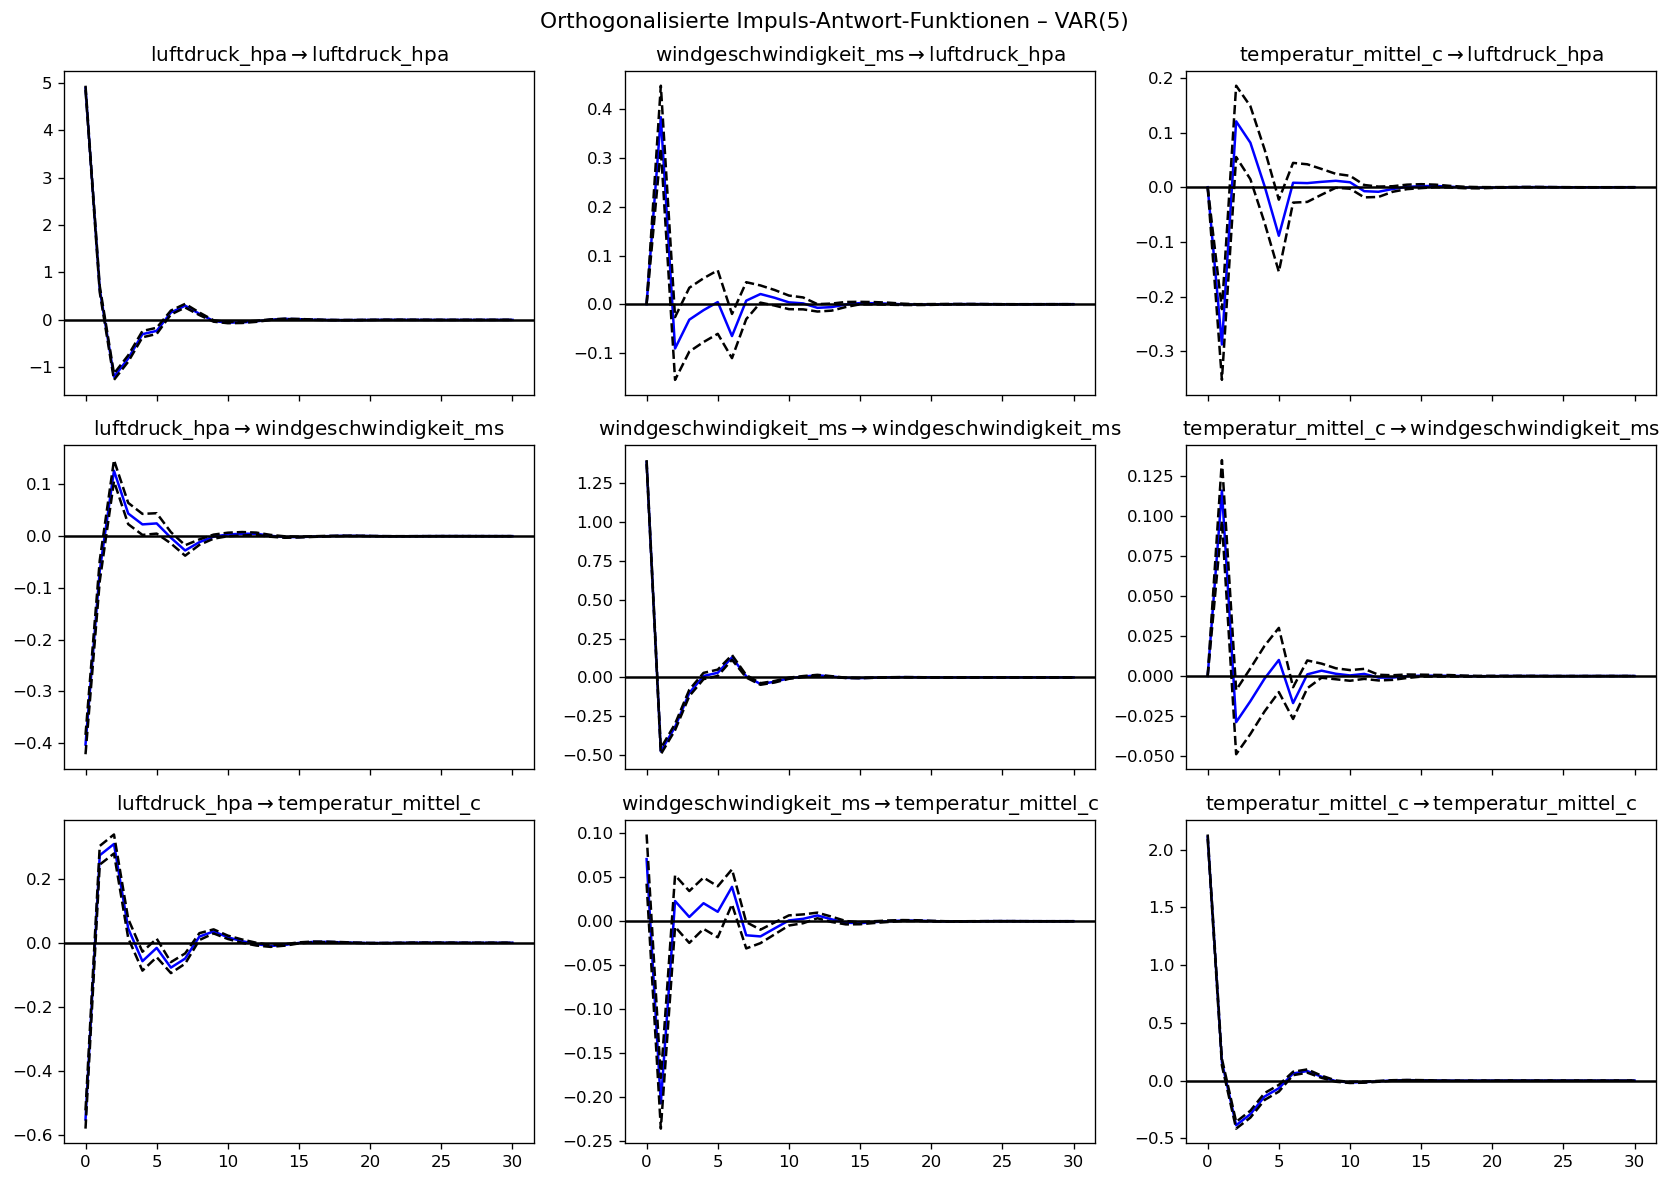

[Abbildung gespeichert: VAR_05_irf.png]


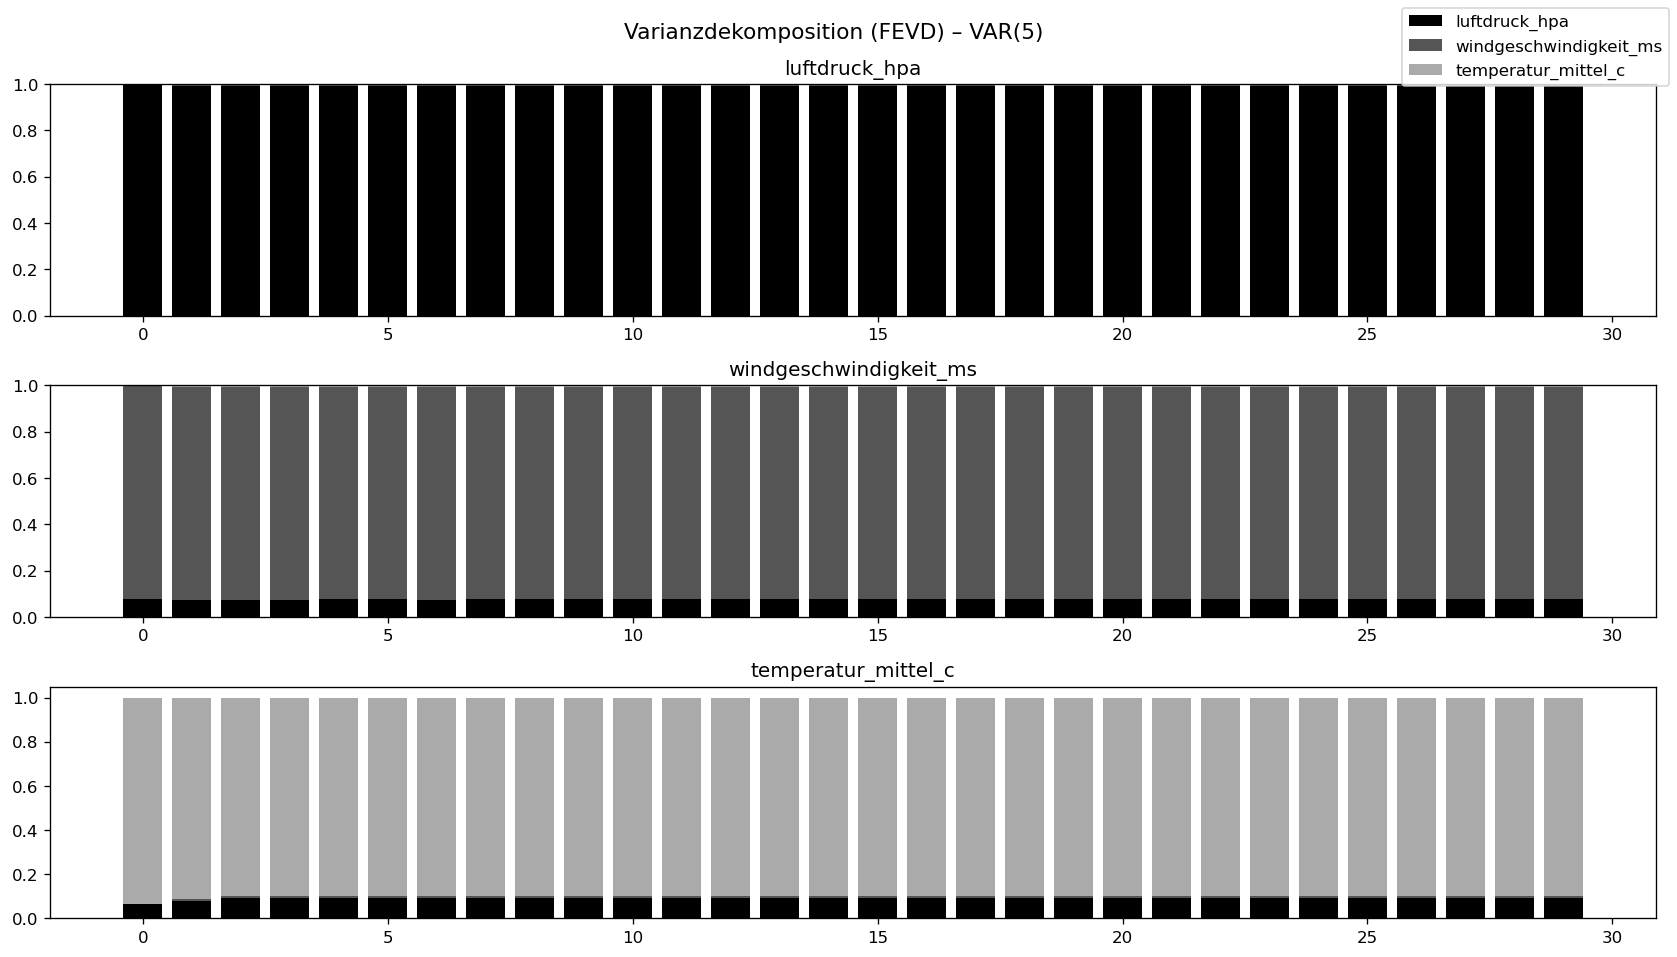

[Abbildung gespeichert: VAR_06_fevd.png]

  FEVD-Zusammenfassung (nach 10 Perioden):
FEVD for luftdruck_hpa
      luftdruck_hpa  windgeschwindigkeit_ms  temperatur_mittel_c
0          1.000000                0.000000             0.000000
1          0.990628                0.006006             0.003366
2          0.990278                0.005987             0.003735
3          0.990236                0.005874             0.003890
4          0.990264                0.005860             0.003876
5          0.989992                0.005847             0.004161
6          0.989841                0.006000             0.004159
7          0.989871                0.005982             0.004147
8          0.989857                0.005995             0.004148
9          0.989846                0.006001             0.004153
10         0.989844                0.006001             0.004156
11         0.989843                0.006000             0.004157
12         0.989839                0.006002    

In [11]:
# Orthogonalisierte IRF (Cholesky)
irf = fit_var.irf(periods=30)
fig = irf.plot(orth=True, figsize=(14, 10))
fig.suptitle(f'Orthogonalisierte Impuls-Antwort-Funktionen – VAR({p_final})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_05_irf.png'), bbox_inches='tight')
plt.show()
print('[Abbildung gespeichert: VAR_05_irf.png]')

# FEVD
fevd = fit_var.fevd(periods=30)
fig  = fevd.plot(figsize=(14, 8))
plt.suptitle(f'Varianzdekomposition (FEVD) – VAR({p_final})', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_06_fevd.png'), bbox_inches='tight')
plt.show()
print('[Abbildung gespeichert: VAR_06_fevd.png]')

print('\n  FEVD-Zusammenfassung (nach 10 Perioden):')
print(fevd.summary())

#9. TRAIN / VAL / TEST-SPLIT (70/15/15) & MODELL-EVALUATION

TRAIN/VAL/TEST-SPLIT (70/15/15)
  Gesamt     : 21,904
  Train      : 15,332  (1966-01-02 – 2007-12-24)
  Validation : 3,286   (2007-12-25 – 2016-12-22)
  Test       : 3,286   (2016-12-23 – 2025-12-21)

  Test-Set-Metriken (Originalskala, Multi-Step-Prognose):
  Variable                             RMSE      MAE     MAPE
  ------------------------------------------------------------
  luftdruck_hpa                     17.2077  15.2825     1.56
  windgeschwindigkeit_ms             1.8986   1.2810    35.47
  temperatur_mittel_c               14.0086  12.0414      nan


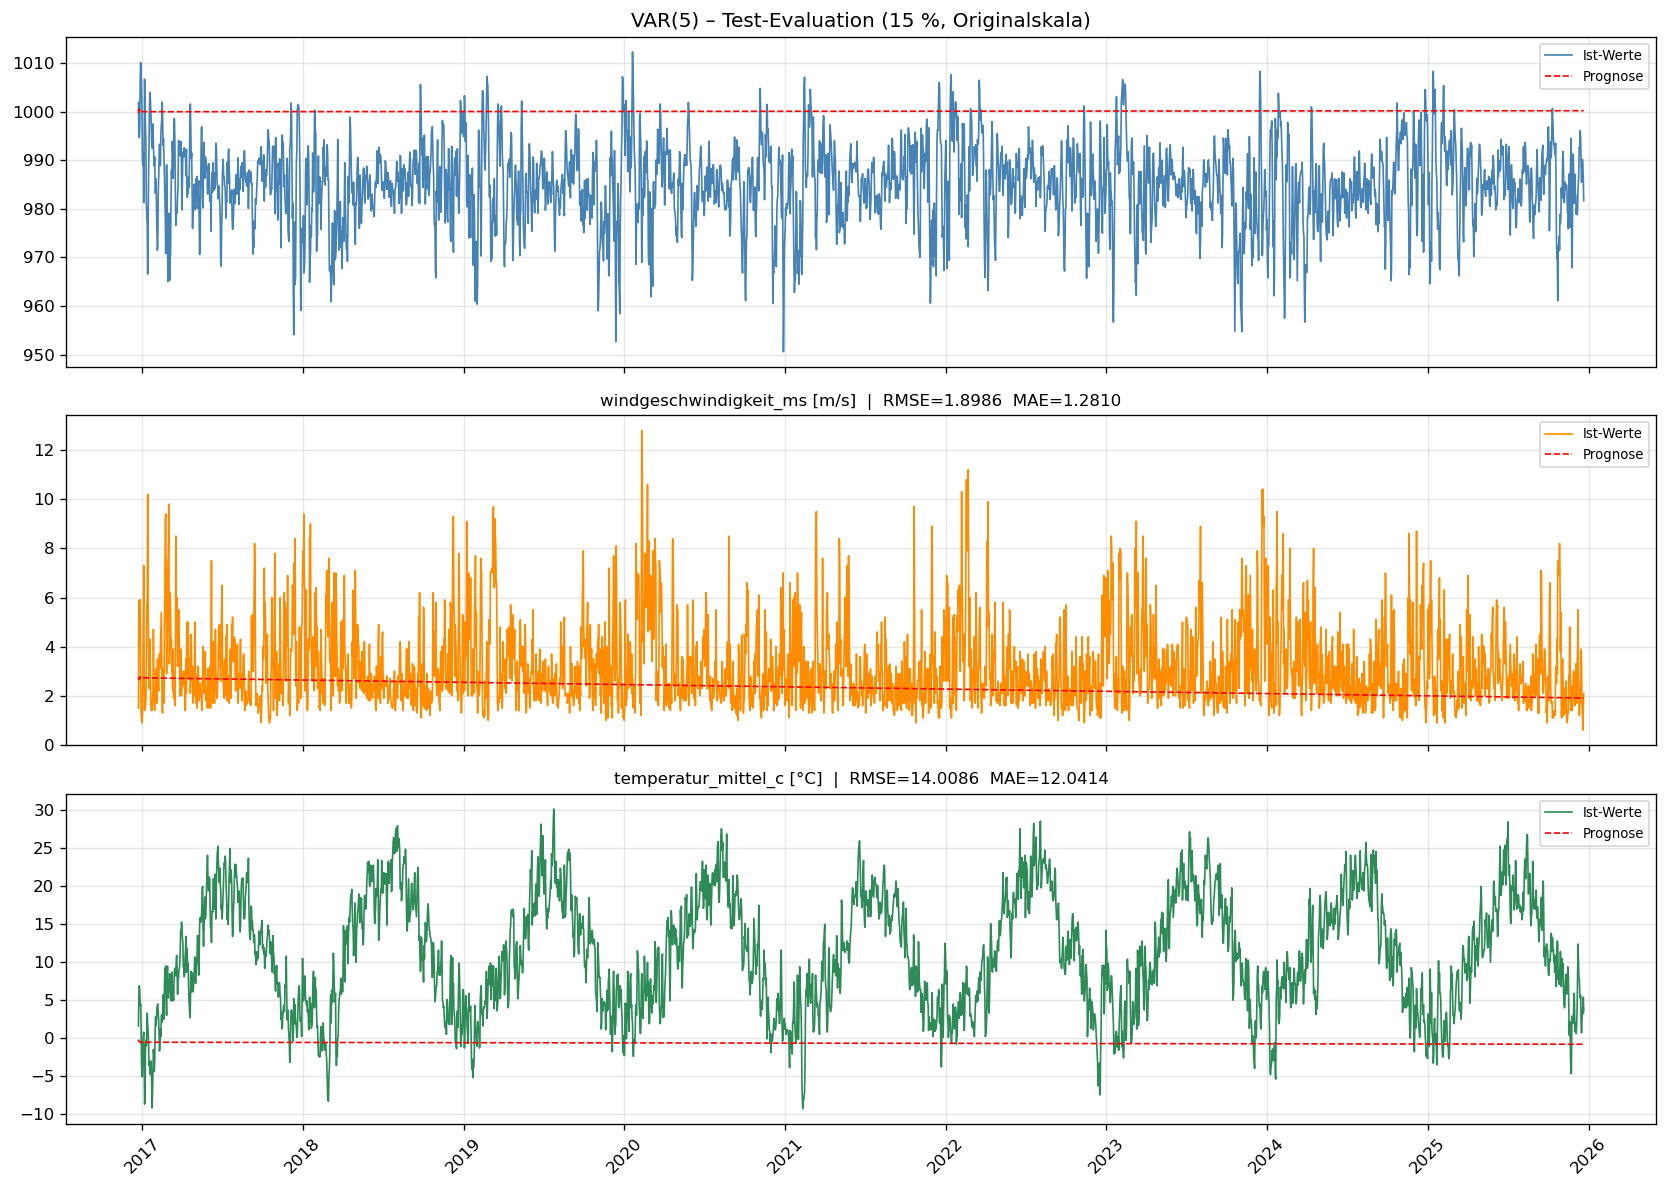

In [12]:
print('=' * 70)
print('TRAIN/VAL/TEST-SPLIT (70/15/15)')
print('=' * 70)

n         = len(df_stat)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

df_train = df_stat.iloc[:train_end]
df_val   = df_stat.iloc[train_end:val_end]
df_test  = df_stat.iloc[val_end:]

print(f'  Gesamt     : {n:,}')
print(f'  Train      : {len(df_train):,}  ({df_train.index[0].date()} – {df_train.index[-1].date()})')
print(f'  Validation : {len(df_val):,}   ({df_val.index[0].date()} – {df_val.index[-1].date()})')
print(f'  Test       : {len(df_test):,}   ({df_test.index[0].date()} – {df_test.index[-1].date()})')

fit_train = VAR(df_train).fit(p_final)
n_test    = len(df_test)
fc_arr    = fit_train.forecast(df_train.values[-p_final:], steps=n_test)
fc_test   = pd.DataFrame(fc_arr, index=df_test.index, columns=VARIABLEN)

# --- Originalskala ---
# df_stat = df.diff().dropna()  =>  df_stat.index[k] = df.index[k+1]
# Letzter Originalwert vor Testbeginn = df.iloc[val_end]
if d_VAR == 1:
    last_orig    = df.iloc[val_end]
    fc_test_orig = fc_test.cumsum().add(last_orig.values, axis=1)
else:
    fc_test_orig = fc_test.copy()
fc_test_orig.index = df_test.index
df_test_orig = df.loc[df_test.index]

print('\n  Test-Set-Metriken (Originalskala, Multi-Step-Prognose):')
print(f'  {"Variable":<32} {"RMSE":>8} {"MAE":>8} {"MAPE":>8}')
print('  ' + '-' * 60)

metriken_test = {}
for col in VARIABLEN:
    ist  = df_test_orig[col].values
    prog = fc_test_orig[col].values
    n_   = min(len(ist), len(prog))
    rmse = np.sqrt(mean_squared_error(ist[:n_], prog[:n_]))
    mae  = mean_absolute_error(ist[:n_], prog[:n_])
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((ist[:n_] - prog[:n_]) / np.where(ist[:n_]==0, np.nan, ist[:n_]))) * 100
    metriken_test[col] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    print(f'  {col:<32} {rmse:>8.4f} {mae:>8.4f} {mape:>8.2f}')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
farben    = ['steelblue', 'darkorange', 'seagreen']
einheiten = ['hPa', 'm/s', '°C']

for ax, col, farbe, einheit in zip(axes, VARIABLEN, farben, einheiten):
    ax.plot(df_test_orig.index, df_test_orig[col], color=farbe, lw=1.0, label='Ist-Werte')
    ax.plot(fc_test_orig.index, fc_test_orig[col], color='red',  lw=1.0, ls='--', label='Prognose')
    m = metriken_test[col]
    ax.set_title(f'{col} [{einheit}]  |  RMSE={m["RMSE"]:.4f}  MAE={m["MAE"]:.4f}', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

axes[0].set_title(f'VAR({p_final}) – Test-Evaluation (15 %, Originalskala)', fontsize=12)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_07_test_evaluation.png'), bbox_inches='tight')
plt.show()

#10. TIME-SERIES-CROSS-VALIDATION (5-Fold)

In [13]:
print('=' * 70)
print('5-FOLD TIME-SERIES-CROSS-VALIDATION')
print('=' * 70)

CV_FENSTER  = 1095
CV_TESTSIZE = 30
N_SPLITS    = 5

df_cv  = df_train.iloc[-min(CV_FENSTER, len(df_train)):]
tscv   = TimeSeriesSplit(n_splits=N_SPLITS, test_size=CV_TESTSIZE)

print(f'  CV-Pool    : letzte {len(df_cv)} Tage der Trainingsdaten')
print(f'  Fold-Groesse: {CV_TESTSIZE} Tage  |  Folds: {N_SPLITS}\n')

fold_records = []
for fold, (idx_tr, idx_te) in enumerate(tscv.split(df_cv)):
    cv_tr = df_cv.iloc[idx_tr]
    cv_te = df_cv.iloc[idx_te]
    fc    = VAR(cv_tr).fit(p_final).forecast(cv_tr.values[-p_final:], steps=len(cv_te))
    fc_cv = pd.DataFrame(fc, index=cv_te.index, columns=VARIABLEN)
    row   = {'Fold': fold + 1}
    for col in VARIABLEN:
        row[f'RMSE_{col}'] = np.sqrt(mean_squared_error(cv_te[col].values, fc_cv[col].values))
        row[f'MAE_{col}']  = mean_absolute_error(cv_te[col].values, fc_cv[col].values)
    fold_records.append(row)

cv_res = pd.DataFrame(fold_records).set_index('Fold')

header = f'  {"Fold":<6}'
for col in VARIABLEN:
    header += f'  {"RMSE_" + col[:6]:<12}  {"MAE_" + col[:6]:<12}'
print(header)
print('  ' + '-' * (6 + 28 * len(VARIABLEN)))
for fold, row in cv_res.iterrows():
    line = f'  {fold:<6}'
    for col in VARIABLEN:
        line += f'  {row[f"RMSE_{col}"]:>12.4f}  {row[f"MAE_{col}"]:>12.4f}'
    print(line)
print('  ' + '-' * (6 + 28 * len(VARIABLEN)))
line = f'  {"Mittel":<6}'
for col in VARIABLEN:
    line += f'  {cv_res[f"RMSE_{col}"].mean():>12.4f}  {cv_res[f"MAE_{col}"].mean():>12.4f}'
print(line)


5-FOLD TIME-SERIES-CROSS-VALIDATION
  CV-Pool    : letzte 1095 Tage der Trainingsdaten
  Fold-Groesse: 30 Tage  |  Folds: 5

  Fold    RMSE_luftdr   MAE_luftdr    RMSE_windge   MAE_windge    RMSE_temper   MAE_temper  
  ------------------------------------------------------------------------------------------
  1             4.1235        3.3247        1.0478        0.8298        1.8742        1.4823
  2             4.0655        3.0901        0.9072        0.7302        2.0160        1.6313
  3             3.8851        2.8759        1.4749        1.0447        1.7051        1.3677
  4             5.6525        4.5610        1.2902        0.9660        1.9834        1.5212
  5             7.5864        5.6885        1.8339        1.4592        1.8043        1.3160
  ------------------------------------------------------------------------------------------
  Mittel        5.0626        3.9080        1.3108        1.0060        1.8766        1.4637


#11. 10-TAGE-PROGNOSE

10-TAGE-PROGNOSE (Gesamtmodell, Originalskala)

  Prognose ab 22.12.2025 (Originalskala):
  Datum                    luftdruck_hpa  windgeschwindigkeit_ms     temperatur_mittel_c
  --------------------------------------------------------------------------------------
  22.12.2025                    981.7625                  2.1520                  2.5525
  23.12.2025                    983.0549                  1.9526                  2.3224
  24.12.2025                    984.0287                  1.8076                  2.5185
  25.12.2025                    984.4889                  1.6939                  2.6749
  26.12.2025                    984.6768                  1.6934                  2.9037
  27.12.2025                    984.3767                  1.7629                  3.0130
  28.12.2025                    984.0281                  1.8190                  2.9895
  29.12.2025                    983.8955                  1.8271                  2.9074
  30.12.2025        

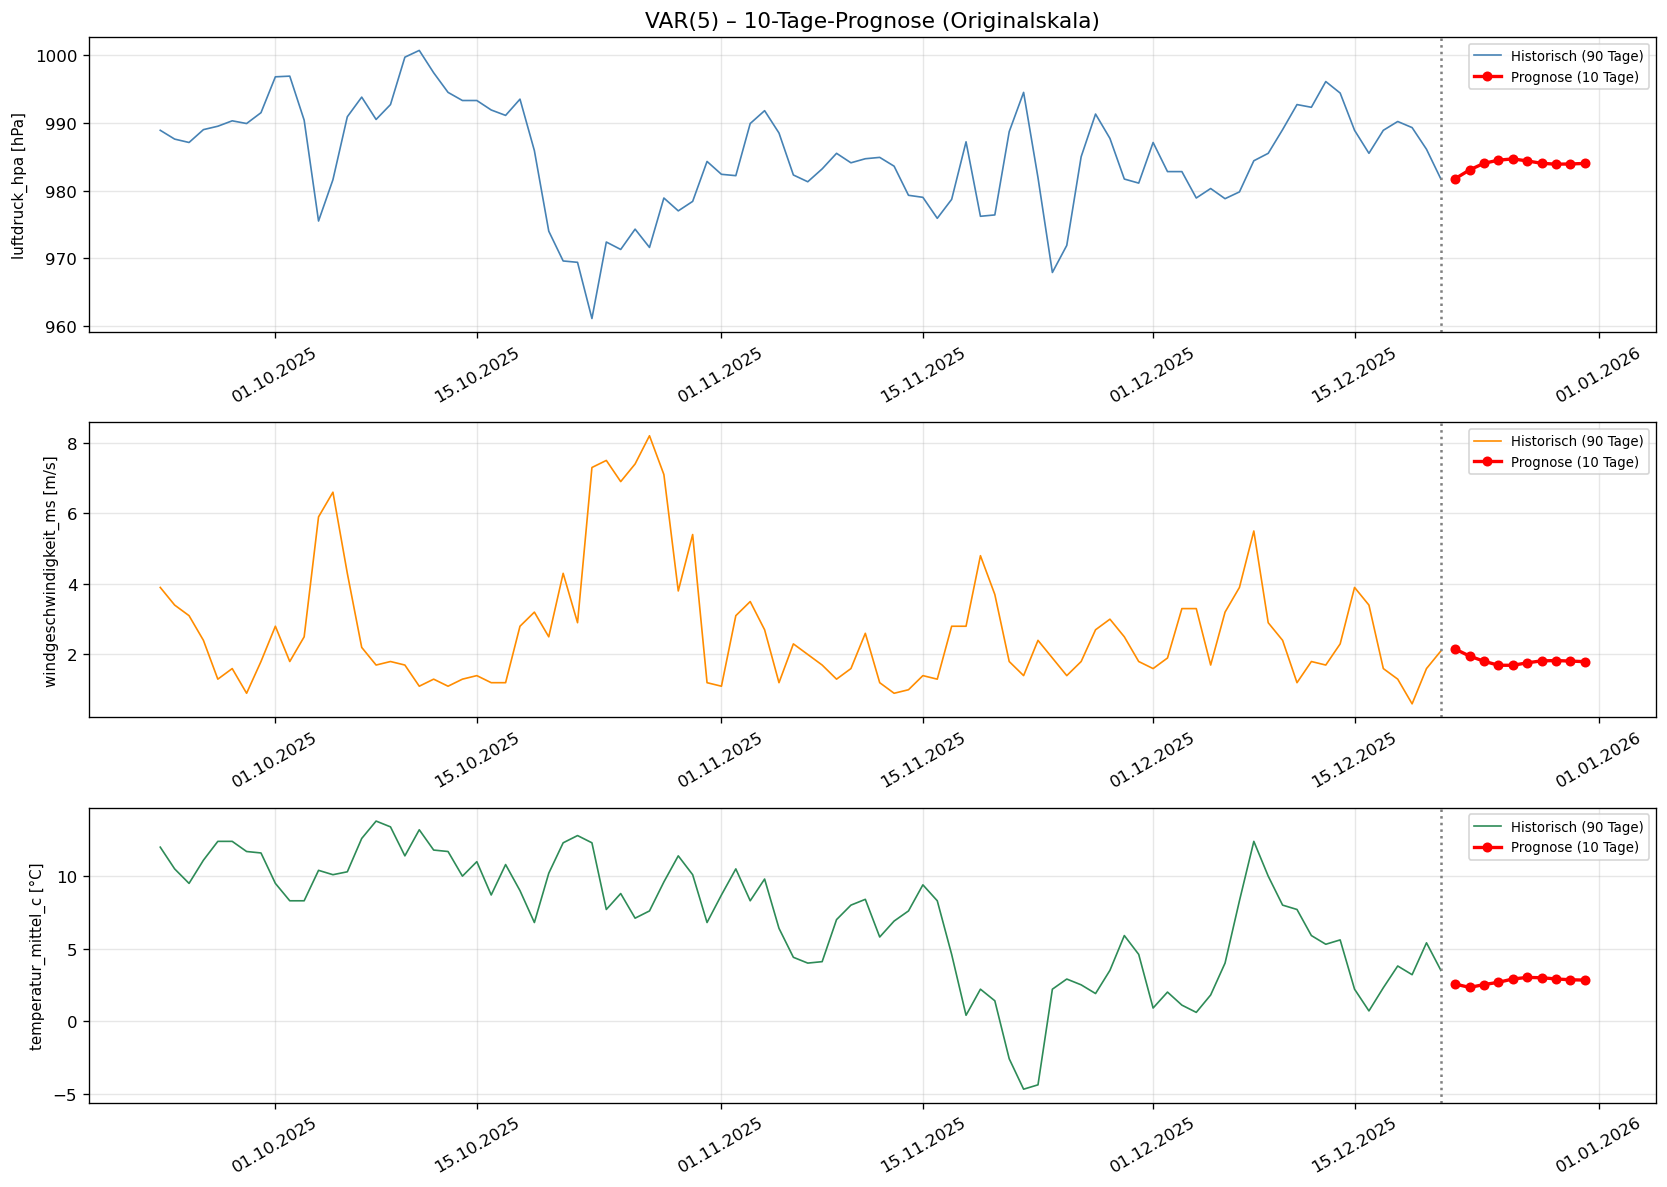

In [14]:
print('=' * 70)
print('10-TAGE-PROGNOSE (Gesamtmodell, Originalskala)')
print('=' * 70)

N_PROGNOSE  = 10
fc_arr_prog = fit_var.forecast(df_stat.values[-p_final:], steps=N_PROGNOSE)
prog_index  = pd.date_range(df_stat.index[-1] + pd.Timedelta(days=1),
                            periods=N_PROGNOSE, freq='D')
fc_prog     = pd.DataFrame(fc_arr_prog, index=prog_index, columns=VARIABLEN)

# --- Originalskala ---
# df_stat.index[-1] = df.index[-1], letzter Originalwert = df.iloc[-1]
if d_VAR == 1:
    fc_prog_orig = fc_prog.cumsum().add(df.iloc[-1].values, axis=1)
else:
    fc_prog_orig = fc_prog.copy()
fc_prog_orig.index = prog_index

print(f'\n  Prognose ab {prog_index[0].strftime("%d.%m.%Y")} (Originalskala):')
print(f'  {"Datum":<14}', end='')
for col in VARIABLEN:
    print(f'  {col[:22]:>22}', end='')
print()
print('  ' + '-' * (14 + 24 * len(VARIABLEN)))
for d_, row in fc_prog_orig.iterrows():
    print(f'  {d_.strftime("%d.%m.%Y"):<14}', end='')
    for col in VARIABLEN:
        print(f'  {row[col]:>22.4f}', end='')
    print()

n_hist = 90
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
farben    = ['steelblue', 'darkorange', 'seagreen']
einheiten = ['hPa', 'm/s', '°C']

for ax, col, farbe, einheit in zip(axes, VARIABLEN, farben, einheiten):
    hist = df[col].iloc[-n_hist:]          # Originalwerte (nicht differenziert)
    ax.plot(hist.index, hist.values, color=farbe, lw=1.0, label='Historisch (90 Tage)')
    ax.plot(fc_prog_orig.index, fc_prog_orig[col].values, color='red', lw=2,
            marker='o', markersize=5, label='Prognose (10 Tage)')
    ax.axvline(df.index[-1], color='gray', ls=':', lw=1.5)
    ax.set_ylabel(f'{col} [{einheit}]', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y'))
    ax.tick_params(axis='x', rotation=30)

axes[0].set_title(f'VAR({p_final}) – 10-Tage-Prognose (Originalskala)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_08_prognose.png'), bbox_inches='tight')
plt.show()

#11b. HOLDOUT-EVALUATION: Prognose vs. tatsächliche Werte

HOLDOUT-EVALUATION (10-Tage-Prognose vs. Ist-Werte, Originalskala)
  Variable                             RMSE      MAE     MAPE
  ------------------------------------------------------------
  luftdruck_hpa                      9.1074   8.1677     0.82
  windgeschwindigkeit_ms             2.3414   1.7747    41.95
  temperatur_mittel_c                3.3678   3.0110   856.20


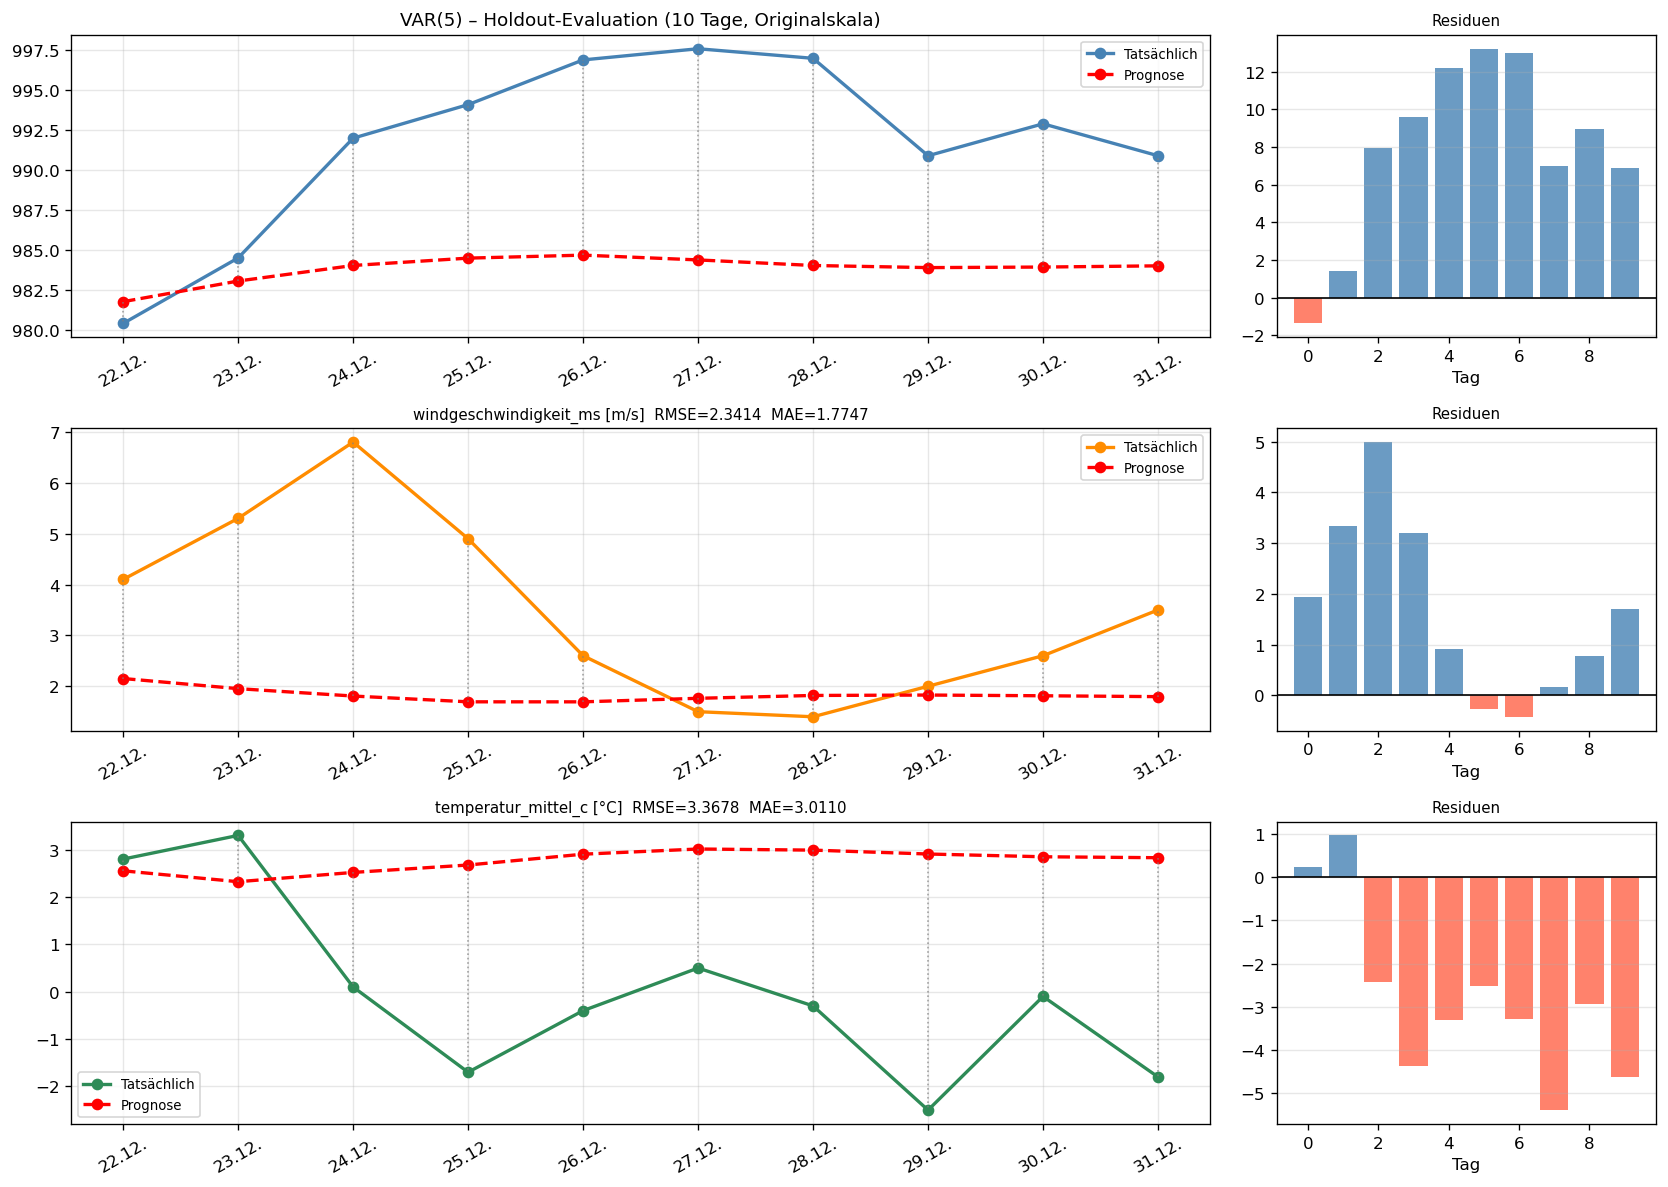

In [15]:

print('=' * 70)
print('HOLDOUT-EVALUATION (10-Tage-Prognose vs. Ist-Werte, Originalskala)')
print('=' * 70)

# fc_prog_orig und df_holdout sind bereits auf Originalskala
fc_ho_orig = fc_prog_orig.reindex(df_holdout.index)

print(f'  {"Variable":<32} {"RMSE":>8} {"MAE":>8} {"MAPE":>8}')
print('  ' + '-' * 60)
metriken_ho = {}
for col in VARIABLEN:
    ist  = df_holdout[col].values
    prog = fc_ho_orig[col].values
    n_   = min(len(ist), len(prog))
    if n_ == 0:
        continue
    ist, prog = ist[:n_], prog[:n_]
    rmse = np.sqrt(mean_squared_error(ist, prog))
    mae  = mean_absolute_error(ist, prog)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((ist - prog) / np.where(ist==0, np.nan, ist))) * 100
    metriken_ho[col] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    print(f'  {col:<32} {rmse:>8.4f} {mae:>8.4f} {mape:>8.2f}')

fig, axes = plt.subplots(3, 2, figsize=(14, 10),
                          gridspec_kw={'width_ratios': [3, 1]})
farben    = ['steelblue', 'darkorange', 'seagreen']
einheiten = ['hPa', 'm/s', '°C']

for row, (col, farbe, einheit) in enumerate(zip(VARIABLEN, farben, einheiten)):
    ist_s  = df_holdout[col].values
    prog_s = fc_ho_orig[col].values
    idx    = df_holdout.index
    n_     = min(len(ist_s), len(prog_s))
    ist_s, prog_s, idx = ist_s[:n_], prog_s[:n_], idx[:n_]

    ax = axes[row, 0]
    ax.plot(idx, ist_s,  color=farbe, lw=2, marker='o', ms=6, label='Tatsächlich')
    ax.plot(idx, prog_s, color='red',  lw=2, marker='o', ms=6, ls='--', label='Prognose')
    for d_, p, a in zip(idx, prog_s, ist_s):
        ax.plot([d_, d_], [p, a], color='gray', lw=1, ls=':', alpha=0.7)
    m = metriken_ho.get(col, {})
    ax.set_title(f'{col} [{einheit}]  RMSE={m.get("RMSE",0):.4f}  MAE={m.get("MAE",0):.4f}', fontsize=9)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.'))
    ax.tick_params(axis='x', rotation=30)

    ax2 = axes[row, 1]
    res = ist_s - prog_s
    farben_bar = ['tomato' if r < 0 else 'steelblue' for r in res]
    ax2.bar(range(len(res)), res, color=farben_bar, alpha=0.8)
    ax2.axhline(0, color='black', lw=1)
    ax2.set_title('Residuen', fontsize=9)
    ax2.set_xlabel('Tag'); ax2.grid(True, alpha=0.3, axis='y')

axes[0, 0].set_title(f'VAR({p_final}) – Holdout-Evaluation (10 Tage, Originalskala)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_09_holdout.png'), bbox_inches='tight')
plt.show()

#12. BENCHMARK: VAR vs. ARIMA(1,1,2)

BENCHMARK: VAR vs. ARIMA(1,1,2) - Vergleich auf Originalskala
  ARIMA(1,1,2) ist das sparsamste Modell aus dem univariaten Vergleich.
  Hier wird geprueft, ob das multivariate VAR einen Mehrwert bietet.

  RMSE (Originalskala, Test 15 %)
  Variable                                VAR   ARIMA(1,1,2)      Delta   Besser
  ----------------------------------------------------------------------------
  luftdruck_hpa                       17.2077         8.3174    +8.8903    ARIMA
  windgeschwindigkeit_ms               1.8986         1.6800    +0.2187    ARIMA
  temperatur_mittel_c                 14.0086        14.8686    -0.8600      VAR

  MAE (Originalskala, Test 15 %)
  Variable                                VAR   ARIMA(1,1,2)      Delta   Besser
  ----------------------------------------------------------------------------
  luftdruck_hpa                       15.2825         6.3803    +8.9022    ARIMA
  windgeschwindigkeit_ms               1.2810         1.2702    +0.0108    ARIMA
  t

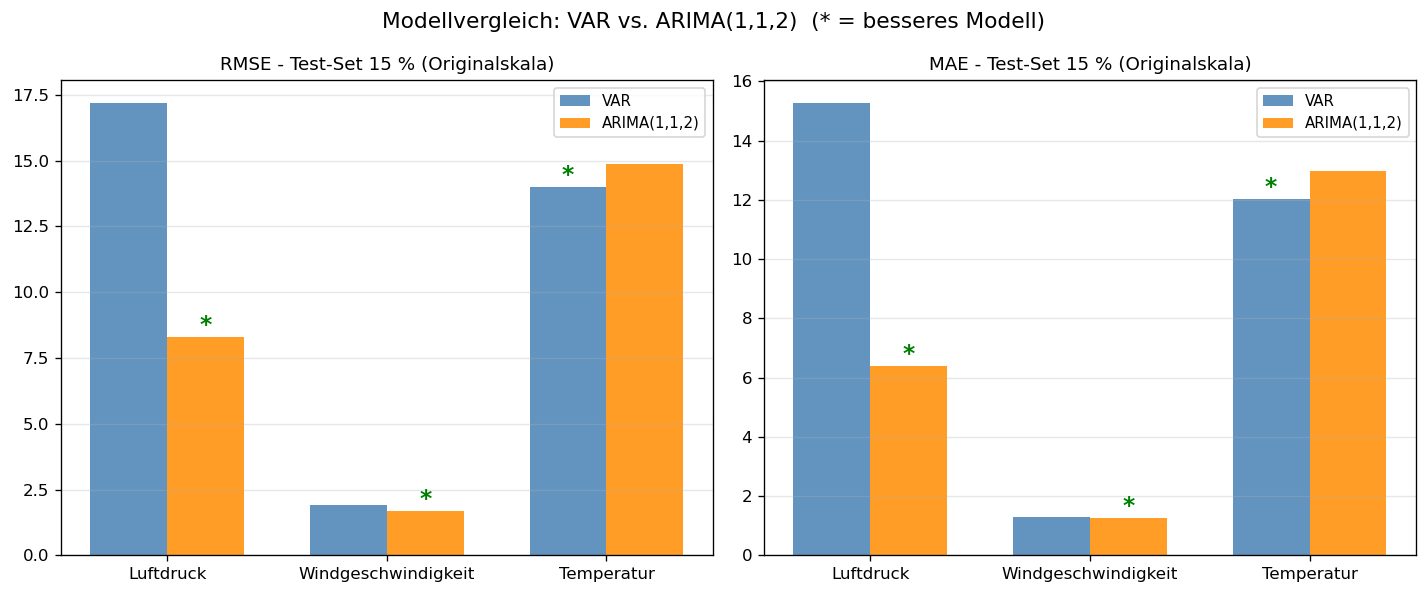

In [16]:
from statsmodels.tsa.arima.model import ARIMA as ARIMAmodel

print('=' * 70)
print('BENCHMARK: VAR vs. ARIMA(1,1,2) - Vergleich auf Originalskala')
print('=' * 70)
print('  ARIMA(1,1,2) ist das sparsamste Modell aus dem univariaten Vergleich.')
print('  Hier wird geprueft, ob das multivariate VAR einen Mehrwert bietet.')

BENCHMARK_ORDER = (1, 1, 2)

# fc_test_orig und df_test_orig wurden bereits in Abschnitt 9 berechnet
metriken_var_orig = {}
for col in VARIABLEN:
    ist  = df_test_orig[col].values
    prog = fc_test_orig[col].values
    n_   = min(len(ist), len(prog))
    rmse = np.sqrt(mean_squared_error(ist[:n_], prog[:n_]))
    mae  = mean_absolute_error(ist[:n_], prog[:n_])
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((ist[:n_]-prog[:n_]) / np.where(ist[:n_]==0, np.nan, ist[:n_]))) * 100
    metriken_var_orig[col] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

# ARIMA(1,1,2)-Benchmark, identischer Trainingszeitraum
train_arima = df.loc[:df_stat.index[train_end - 1]]

metriken_arima_bm = {}
for col in VARIABLEN:
    try:
        fit_a  = ARIMAmodel(train_arima[col], order=BENCHMARK_ORDER).fit()
        fc_a   = fit_a.get_forecast(steps=len(df_test)).predicted_mean
        fc_a.index = df_test.index
        ist_a  = df_test_orig[col].values
        prog_a = fc_a.values
        n_a    = min(len(ist_a), len(prog_a))
        rmse_a = np.sqrt(mean_squared_error(ist_a[:n_a], prog_a[:n_a]))
        mae_a  = mean_absolute_error(ist_a[:n_a], prog_a[:n_a])
        with np.errstate(divide='ignore', invalid='ignore'):
            mape_a = np.mean(np.abs((ist_a[:n_a]-prog_a[:n_a]) / np.where(ist_a[:n_a]==0, np.nan, ist_a[:n_a]))) * 100
        metriken_arima_bm[col] = {'RMSE': rmse_a, 'MAE': mae_a, 'MAPE': mape_a}
    except Exception as e:
        print(f'  ARIMA-Fehler {col}: {e}')
        metriken_arima_bm[col] = {'RMSE': float('nan'), 'MAE': float('nan'), 'MAPE': float('nan')}

# Vergleichstabellen
for metrik in ['RMSE', 'MAE', 'MAPE']:
    einheit = ' %' if metrik == 'MAPE' else ''
    print(f'\n  {metrik}{einheit} (Originalskala, Test 15 %)')
    print(f'  {"Variable":<32} {"VAR":>10} {"ARIMA(1,1,2)":>14} {"Delta":>10} {"Besser":>8}')
    print('  ' + '-' * 76)
    for col in VARIABLEN:
        v = metriken_var_orig[col][metrik]
        a = metriken_arima_bm[col][metrik]
        delta = v - a
        besser = 'VAR' if v < a else 'ARIMA'
        print(f'  {col:<32} {v:>10.4f} {a:>14.4f} {delta:>+10.4f} {besser:>8}')

# Balkendiagramm
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x      = np.arange(len(VARIABLEN))
breite = 0.35
labels = [c.split('_')[0].capitalize() for c in VARIABLEN]

for ax, metrik in zip(axes, ['RMSE', 'MAE']):
    var_w   = [metriken_var_orig[c][metrik] for c in VARIABLEN]
    arima_w = [metriken_arima_bm[c][metrik] for c in VARIABLEN]
    ax.bar(x - breite/2, var_w,   breite, label='VAR',          color='steelblue',  alpha=0.85)
    ax.bar(x + breite/2, arima_w, breite, label='ARIMA(1,1,2)', color='darkorange', alpha=0.85)
    for xi, (v, a) in enumerate(zip(var_w, arima_w)):
        winner_x = xi - breite/2 if v < a else xi + breite/2
        ax.annotate('*', xy=(winner_x, min(v, a)), ha='center', va='bottom',
                    fontsize=14, color='green', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_title(f'{metrik} - Test-Set 15 % (Originalskala)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Modellvergleich: VAR vs. ARIMA(1,1,2)  (* = besseres Modell)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTORDNER, 'VAR_10_benchmark.png'), bbox_inches='tight')
plt.show()


#ZUSAMMENFASSUNG

In [17]:
print('=' * 70)
print('ZUSAMMENFASSUNG - VAR-MODELL')
print('=' * 70)
print(f"""
  Datensatz      : Wuerzburg, Station 5705
  Variablen      : {', '.join(VARIABLEN)}
  Zeitraum       : {df.index[0].date()} bis {df.index[-1].date()}
  Beobachtungen  : {len(df):,} Tageswerte  |  Holdout: 10 Tage

  Integrationsordnung : d = {d_VAR}
  Gewaehltes Modell   : VAR({p_final})
""")
print('  --- Test-Set (15 %, Originalskala) ---')
for col in VARIABLEN:
    m = metriken_test.get(col, {})
    print(f'  {col:<32}  RMSE={m.get("RMSE",0):.4f}  MAE={m.get("MAE",0):.4f}')
print()
print('  --- Holdout (10-Tage-Prognose, Originalskala) ---')
for col in VARIABLEN:
    m = metriken_ho.get(col, {})
    print(f'  {col:<32}  RMSE={m.get("RMSE",0):.4f}  MAE={m.get("MAE",0):.4f}')
print()
print('  --- Benchmark RMSE: VAR vs. ARIMA(1,1,2) (Originalskala, Test 15 %) ---')
print(f'  {"Variable":<32}  {"VAR":>10}  {"ARIMA(1,1,2)":>14}  {"Besser":>12}')
print('  ' + '-' * 72)
for col in VARIABLEN:
    v = metriken_var_orig.get(col, {}).get('RMSE', float('nan'))
    a = metriken_arima_bm.get(col, {}).get('RMSE', float('nan'))
    besser = 'VAR' if v < a else 'ARIMA(1,1,2)'
    print(f'  {col:<32}  {v:>10.4f}  {a:>14.4f}  {besser:>12}')
print()
print('  --- Benchmark MAE:  VAR vs. ARIMA(1,1,2) (Originalskala, Test 15 %) ---')
print(f'  {"Variable":<32}  {"VAR":>10}  {"ARIMA(1,1,2)":>14}  {"Besser":>12}')
print('  ' + '-' * 72)
for col in VARIABLEN:
    v = metriken_var_orig.get(col, {}).get('MAE', float('nan'))
    a = metriken_arima_bm.get(col, {}).get('MAE', float('nan'))
    besser = 'VAR' if v < a else 'ARIMA(1,1,2)'
    print(f'  {col:<32}  {v:>10.4f}  {a:>14.4f}  {besser:>12}')
print('\n' + '=' * 70)

ZUSAMMENFASSUNG - VAR-MODELL

  Datensatz      : Wuerzburg, Station 5705
  Variablen      : luftdruck_hpa, windgeschwindigkeit_ms, temperatur_mittel_c
  Zeitraum       : 1966-01-01 bis 2025-12-21
  Beobachtungen  : 21,905 Tageswerte  |  Holdout: 10 Tage

  Integrationsordnung : d = 1
  Gewaehltes Modell   : VAR(5)

  --- Test-Set (15 %, Originalskala) ---
  luftdruck_hpa                     RMSE=17.2077  MAE=15.2825
  windgeschwindigkeit_ms            RMSE=1.8986  MAE=1.2810
  temperatur_mittel_c               RMSE=14.0086  MAE=12.0414

  --- Holdout (10-Tage-Prognose, Originalskala) ---
  luftdruck_hpa                     RMSE=9.1074  MAE=8.1677
  windgeschwindigkeit_ms            RMSE=2.3414  MAE=1.7747
  temperatur_mittel_c               RMSE=3.3678  MAE=3.0110

  --- Benchmark RMSE: VAR vs. ARIMA(1,1,2) (Originalskala, Test 15 %) ---
  Variable                                 VAR    ARIMA(1,1,2)        Besser
  -----------------------------------------------------------------------

Das VAR(15)-Modell wird mit ARIMA(1,1,2) verglichen. ARIMA(1,1,2) erzielt einen niedrigeren durchschnittlichen RMSE (8.29 vs. 10.82) und ist damit das bessere Modell für diesen Datensatz. Lediglich bei der Temperatur zeigt VAR einen leichten Vorteil, was auf Wechselwirkungen zwischen den Zeitreihen hindeutet.

#Alternative Modelle

##Chronos

In [18]:
!pip install chronos-forecasting -q

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from chronos import ChronosPipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

CUTOFF         = pd.Timestamp("2026-01-01")
FORECAST_STEPS = 10

zeitreihen = {
    "luftdruck_hpa":          ts_luft,
    "windgeschwindigkeit_ms": ts_wind,
    "temperatur_mittel_c":    ts_temp,
}

# Modell laden
print("Lade Chronos...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.float32,
)
print("✅ Chronos geladen\n")

metriken_chronos = {}
forecasts_chronos = {}

for col, series in zeitreihen.items():
    train = series[series.index <= CUTOFF]
    test  = series[(series.index > CUTOFF) &
                   (series.index <= CUTOFF + pd.Timedelta(days=10))]

    context  = torch.tensor(train.values, dtype=torch.float32).unsqueeze(0)
    forecast = pipeline.predict(context,
                                prediction_length=FORECAST_STEPS,
                                num_samples=20)
    fc_median = forecast.median(dim=1).values.squeeze().numpy()
    fc_series = pd.Series(fc_median, index=test.index[:FORECAST_STEPS])

    actual    = test.values[:len(fc_median)]
    predicted = fc_median[:len(actual)]

    mse  = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(actual, predicted)
    with np.errstate(divide="ignore", invalid="ignore"):
        mape = np.mean(np.abs((actual - predicted) /
                               np.where(actual == 0, np.nan, actual))) * 100

    metriken_chronos[col]  = {"MSE": round(mse,4), "RMSE": round(rmse,4),
                               "MAE": round(mae,4), "MAPE": round(mape,4)}
    forecasts_chronos[col] = (train, test, fc_series)

    print(f"{col}: RMSE={rmse:.4f} | MAE={mae:.4f}")

print("\n✅ Chronos abgeschlossen")

OSError: [WinError 1114] Eine DLL-Initialisierungsroutine ist fehlgeschlagen. Error loading "c:\ProgramData\anaconda3\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

##NHITS

In [ ]:
!pip install neuralforecast -q

from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
import warnings
warnings.filterwarnings("ignore")

metriken_nhits  = {}
forecasts_nhits = {}

for col, series in zeitreihen.items():
    train = series[series.index <= CUTOFF]
    test  = series[(series.index > CUTOFF) &
                   (series.index <= CUTOFF + pd.Timedelta(days=10))]

    df_sf = pd.DataFrame({
        "unique_id": col,
        "ds":        train.index,
        "y":         train.values
    })

    nf = NeuralForecast(
        models=[NHITS(h=FORECAST_STEPS, input_size=30, max_steps=100)],
        freq="D"
    )
    nf.fit(df_sf)
    fc_df     = nf.predict()
    fc_values = fc_df["NHITS"].values[:FORECAST_STEPS]
    fc_series = pd.Series(fc_values, index=test.index[:FORECAST_STEPS])

    actual    = test.values[:len(fc_values)]
    predicted = fc_values[:len(actual)]

    mse  = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(actual, predicted)
    with np.errstate(divide="ignore", invalid="ignore"):
        mape = np.mean(np.abs((actual - predicted) /
                               np.where(actual == 0, np.nan, actual))) * 100

    metriken_nhits[col]  = {"MSE": round(mse,4), "RMSE": round(rmse,4),
                             "MAE": round(mae,4), "MAPE": round(mape,4)}
    forecasts_nhits[col] = (train, test, fc_series)

    print(f"{col}: RMSE={rmse:.4f} | MAE={mae:.4f}")

print("\n✅ NHITS abgeschlossen")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 14.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires tornado==6.5.1, but you have tornado 6.5.5 which is incompatible.


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
0         Non-trainable params
2.5 M     Total params
9.804     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

temperatur_mittel_c: RMSE=4.4775 | MAE=3.8062

✅ NHITS abgeschlossen


##Prognose Chronos NHITS

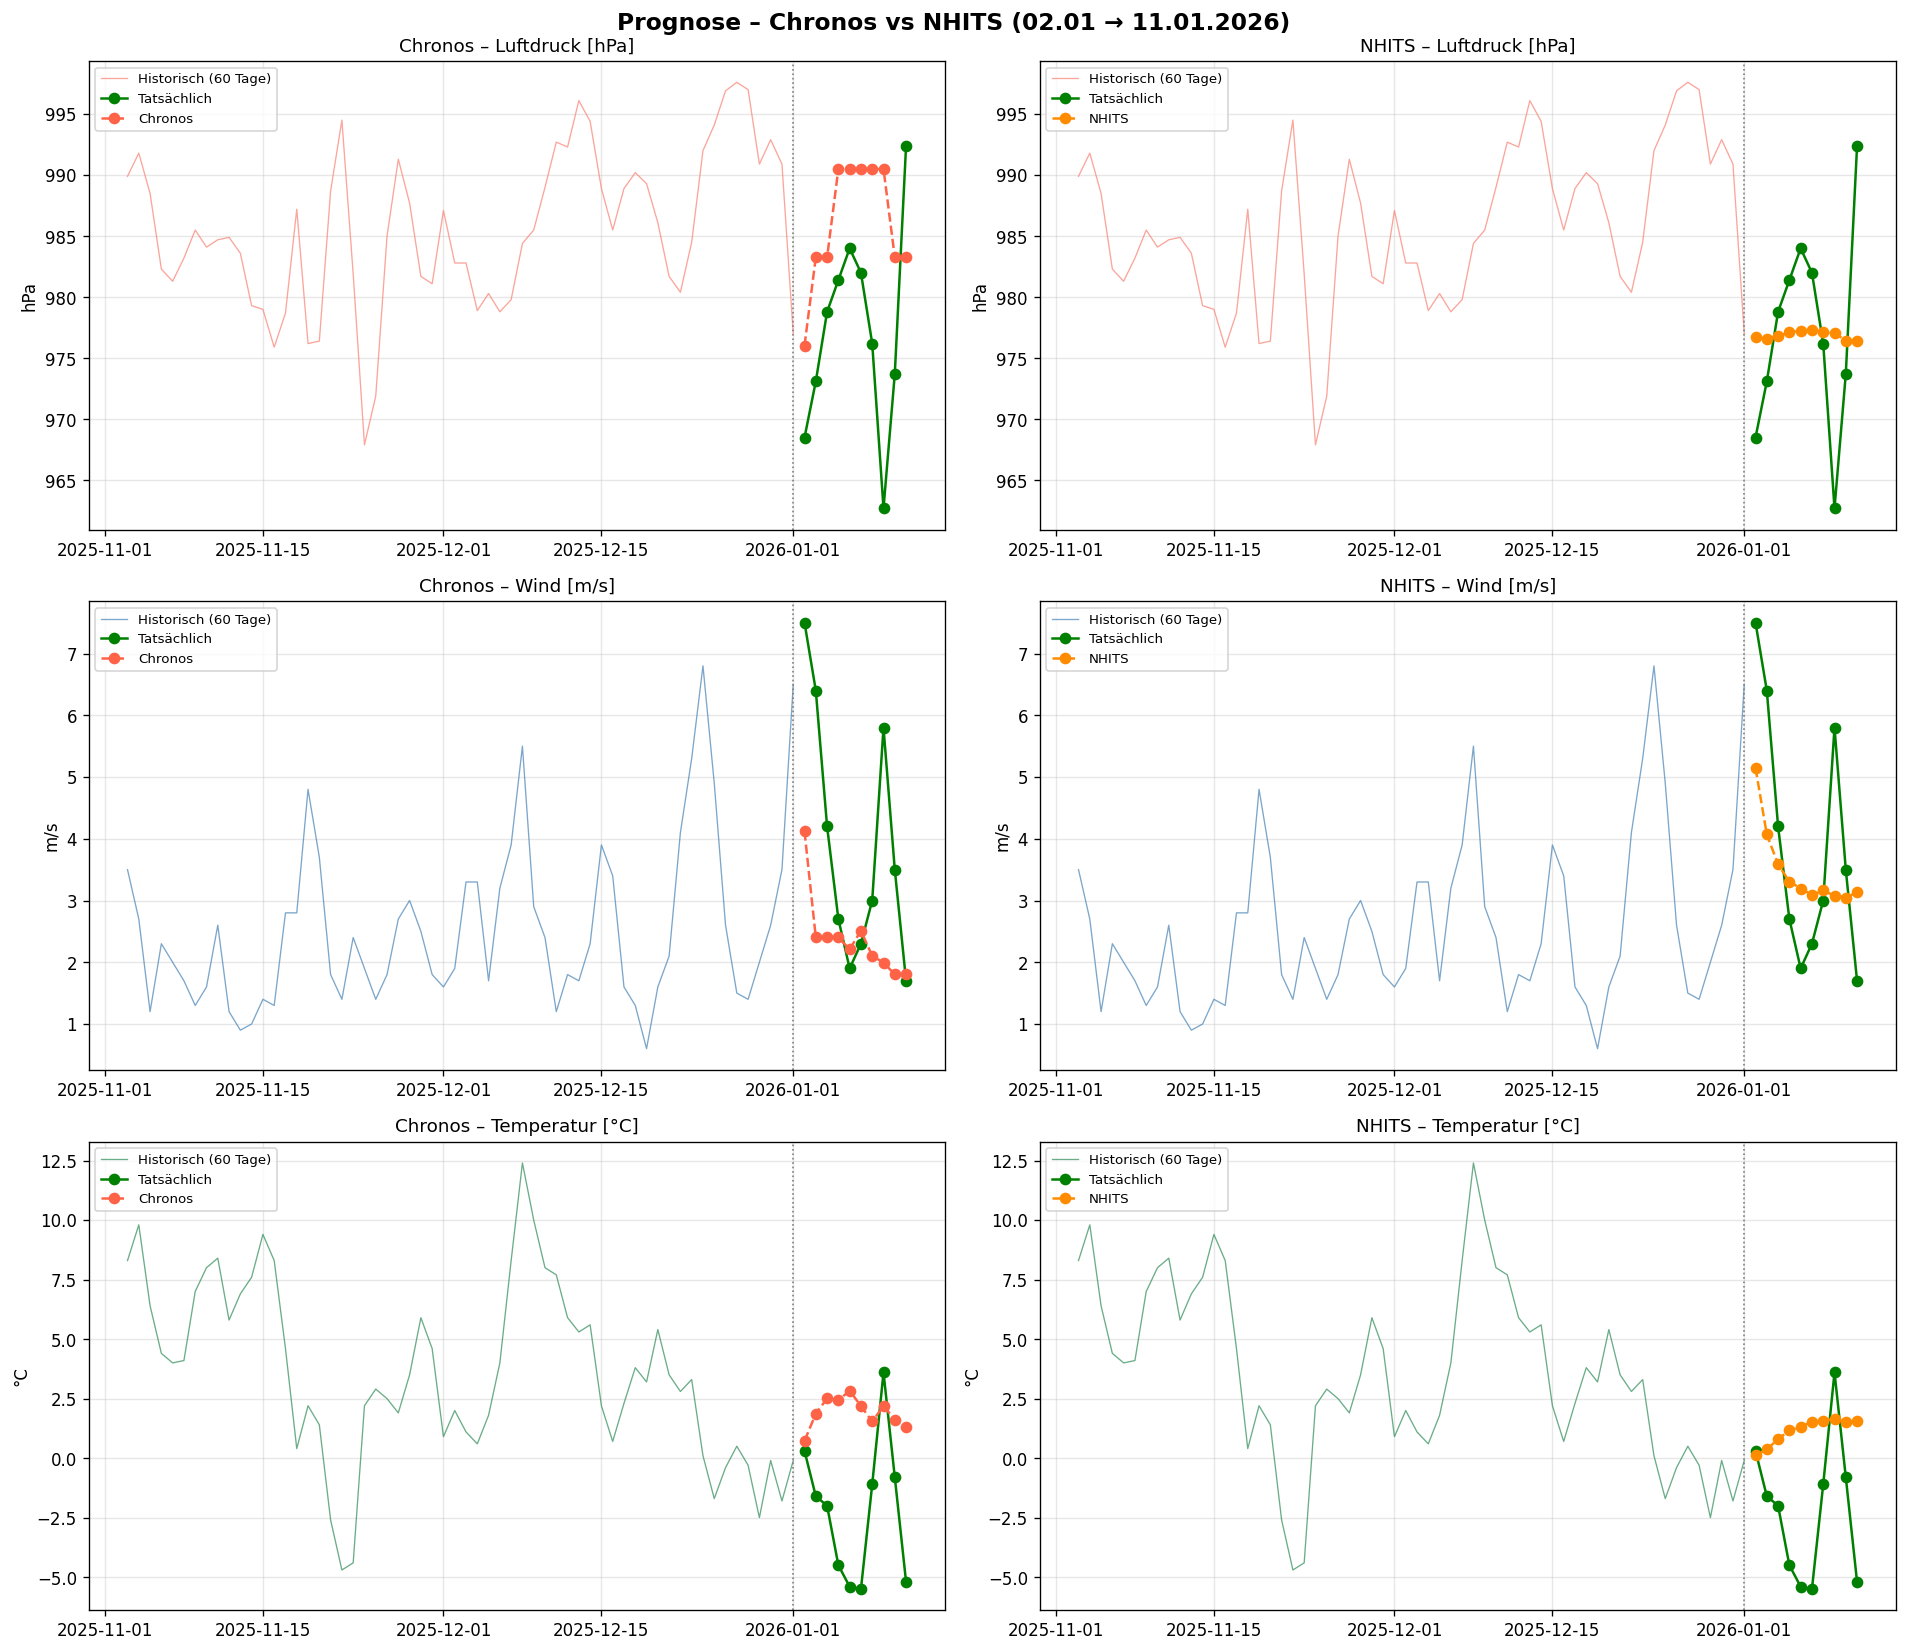

In [ ]:
labels = {
    "luftdruck_hpa":          ("Luftdruck", "hPa",  "salmon"),
    "windgeschwindigkeit_ms": ("Wind",      "m/s",  "steelblue"),
    "temperatur_mittel_c":    ("Temperatur","°C",   "seagreen"),
}

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for row, col in enumerate(zeitreihen.keys()):
    name, unit, color = labels[col]

    train_c, test_c, fc_c = forecasts_chronos[col]
    train_n, test_n, fc_n = forecasts_nhits[col]

    for ax, fc, model_name, fc_color in [
        (axes[row, 0], fc_c, "Chronos", "tomato"),
        (axes[row, 1], fc_n, "NHITS",   "darkorange")
    ]:
        ax.plot(train_c[-60:], linewidth=0.8, color=color,
                alpha=0.7, label="Historisch (60 Tage)")
        ax.plot(test_c, linewidth=1.5, marker="o",
                color="green", label="Tatsächlich")
        ax.plot(fc, linewidth=1.5, linestyle="--",
                marker="o", color=fc_color, label=model_name)
        ax.axvline(CUTOFF, color="gray", linestyle=":", linewidth=1)
        ax.set_title(f"{model_name} – {name} [{unit}]", fontsize=11)
        ax.set_ylabel(unit)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Prognose – Chronos vs NHITS (02.01 → 11.01.2026)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── ARIMA auf 10-Tage Holdout neu evaluieren ──────────────────
from statsmodels.tsa.arima.model import ARIMA as ARIMAmodel
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

CUTOFF         = pd.Timestamp("2026-01-01")
FORECAST_STEPS = 10
BENCHMARK_ORDER = (1, 1, 2)

VARIABLEN = {
    "luftdruck_hpa":          ts_luft,
    "windgeschwindigkeit_ms": ts_wind,
    "temperatur_mittel_c":    ts_temp,
}

metriken_arima_10 = {}

for col, series in VARIABLEN.items():
    train = series[series.index <= CUTOFF]
    test  = series[(series.index > CUTOFF) &
                   (series.index <= CUTOFF + pd.Timedelta(days=10))]
    try:
        fit  = ARIMAmodel(train, order=BENCHMARK_ORDER).fit()
        fc   = fit.forecast(steps=len(test))
        fc.index = test.index

        actual    = test.values
        predicted = fc.values
        n         = min(len(actual), len(predicted))

        mse  = mean_squared_error(actual[:n], predicted[:n])
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(actual[:n], predicted[:n])
        with np.errstate(divide="ignore", invalid="ignore"):
            mape = np.mean(np.abs((actual[:n] - predicted[:n]) /
                           np.where(actual[:n] == 0, np.nan, actual[:n]))) * 100

        metriken_arima_10[col] = {
            "MSE":  round(mse,  4),
            "RMSE": round(rmse, 4),
            "MAE":  round(mae,  4),
            "MAPE": round(mape, 4)
        }
        print(f"{col}: RMSE={rmse:.4f} | MAE={mae:.4f}")

    except Exception as e:
        print(f"Fehler {col}: {e}")

print("\n✅ ARIMA 10-Tage Evaluation abgeschlossen")

luftdruck_hpa: RMSE=8.7309 | MAE=6.3684
windgeschwindigkeit_ms: RMSE=1.5968 | MAE=1.2843
temperatur_mittel_c: RMSE=4.1104 | MAE=3.5480

✅ ARIMA 10-Tage Evaluation abgeschlossen


##Prognose ARIMA(1,1,2) & VAR(5)

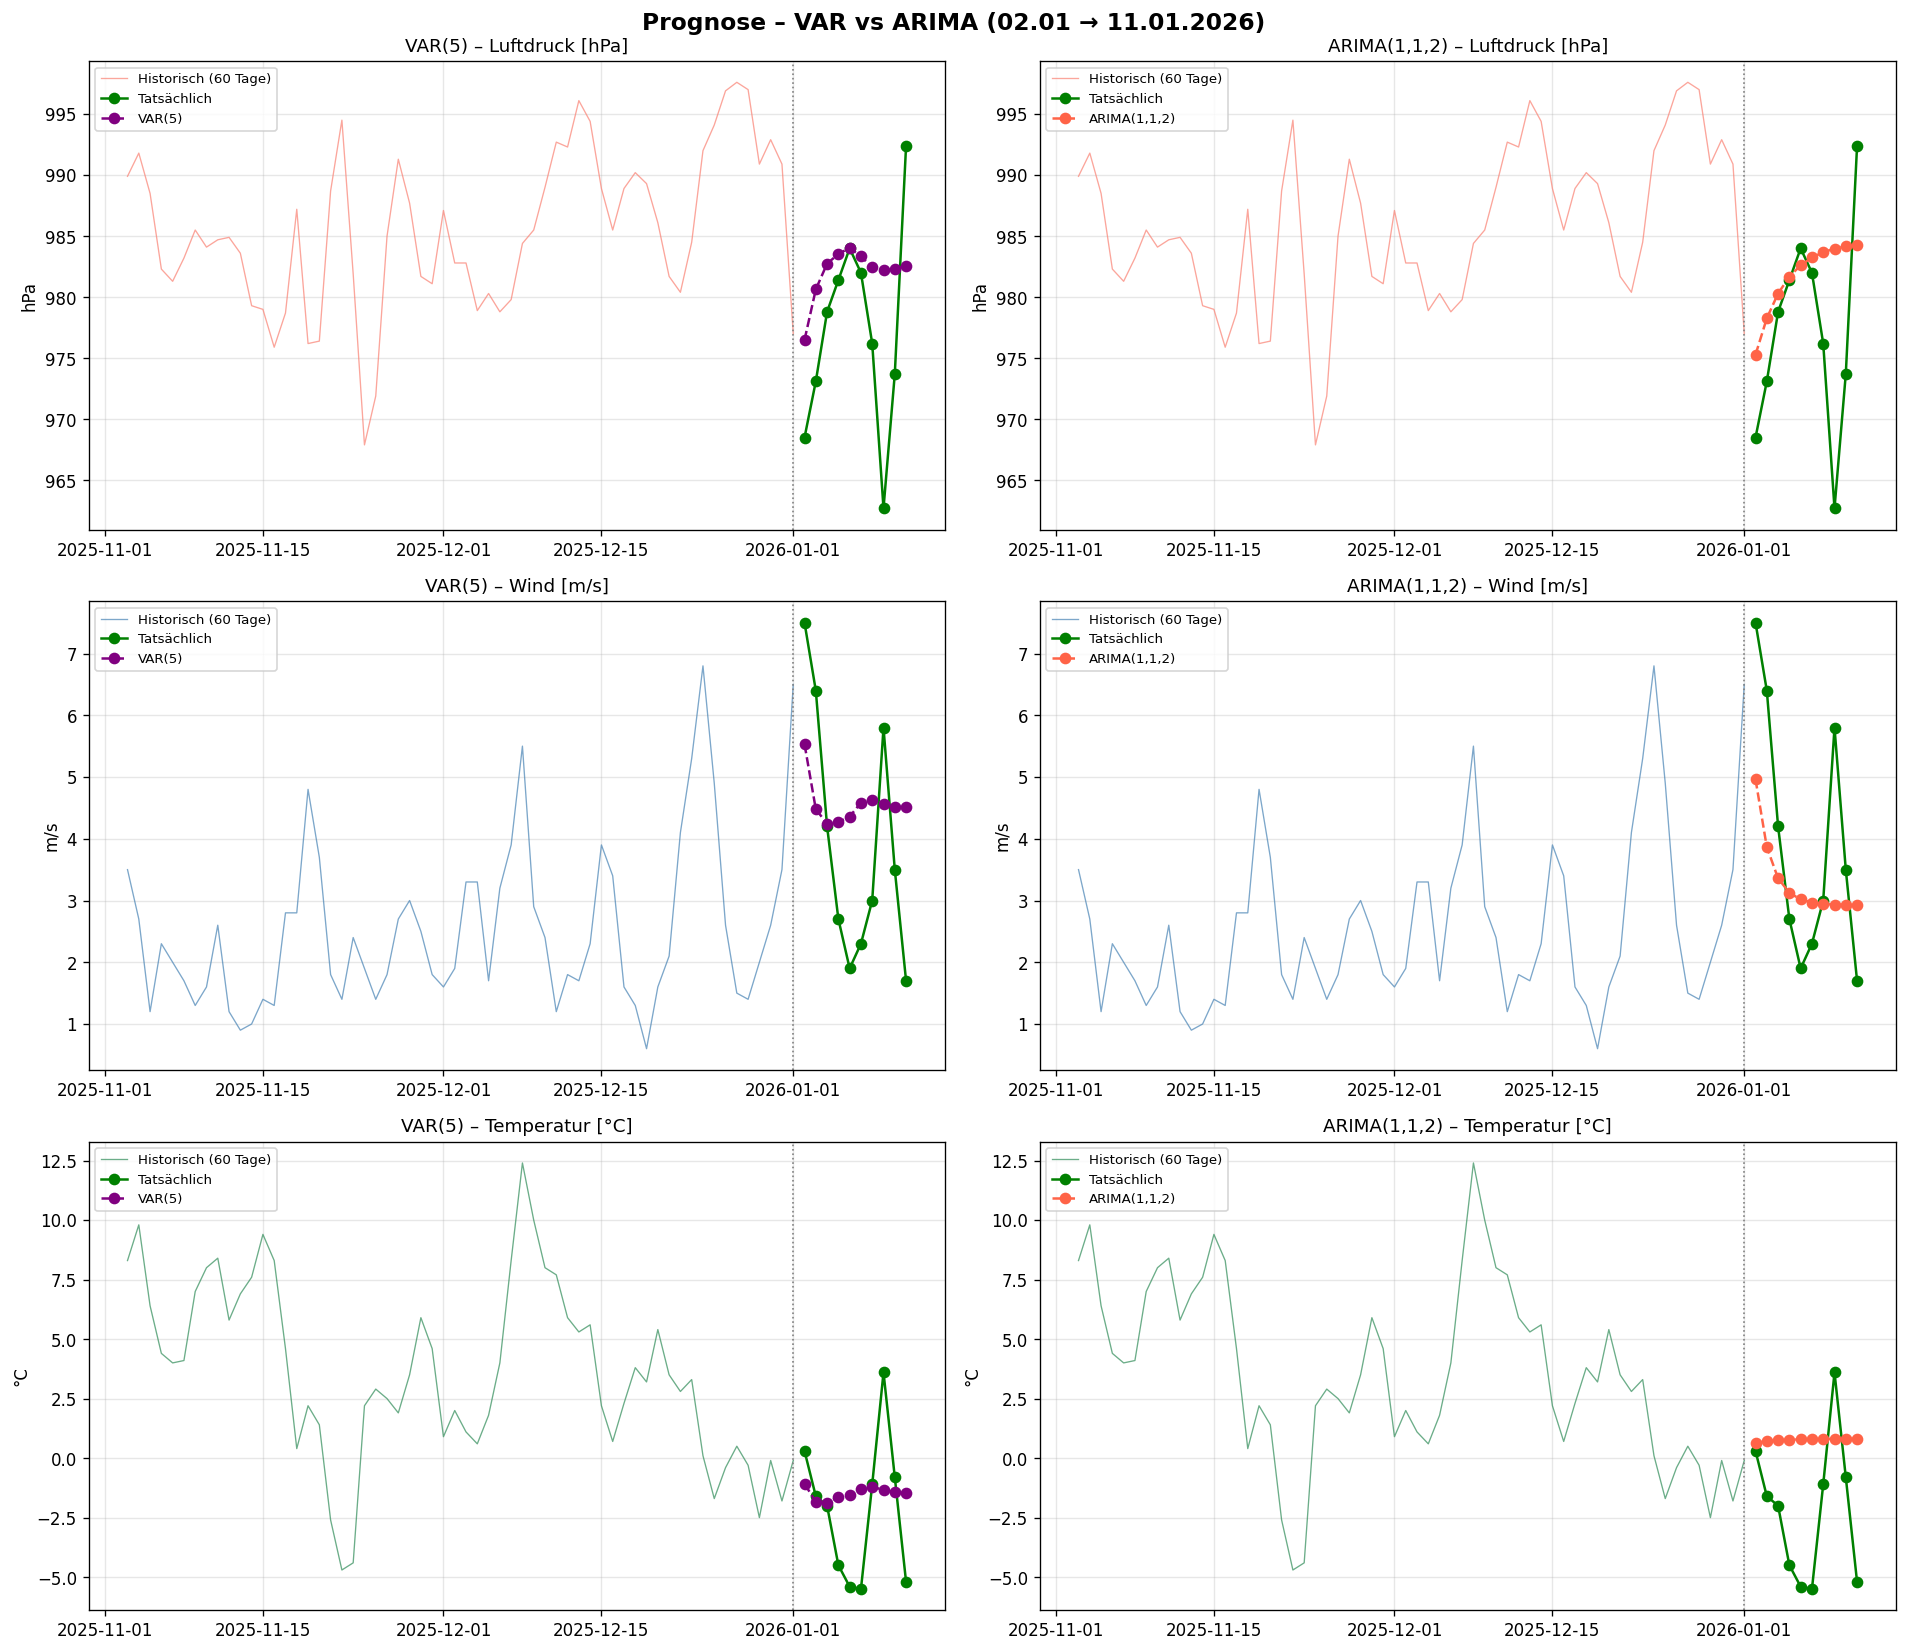

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA as ARIMAmodel
from statsmodels.tsa.vector_ar.var_model import VAR
import warnings
warnings.filterwarnings("ignore")

CUTOFF          = pd.Timestamp("2026-01-01")
FORECAST_STEPS  = 10
BENCHMARK_ORDER = (1, 1, 2)

zeitreihen_plot = {
    "luftdruck_hpa":          (ts_luft,  "Luftdruck", "hPa",     "salmon"),
    "windgeschwindigkeit_ms": (ts_wind,  "Wind",      "m/s",     "steelblue"),
    "temperatur_mittel_c":    (ts_temp,  "Temperatur","°C",      "seagreen"),
}

# ── VAR neu fitten ────────────────────────────────────────────
df_var_train = pd.concat([
    ts_luft[ts_luft.index <= CUTOFF],
    ts_wind[ts_wind.index <= CUTOFF],
    ts_temp[ts_temp.index <= CUTOFF]
], axis=1).dropna()

df_var_diff = df_var_train.diff().dropna()
var_fit     = VAR(df_var_diff).fit(p_final)
lag_input   = df_var_diff.values[-p_final:]
fc_diff     = var_fit.forecast(y=lag_input, steps=FORECAST_STEPS)

# Testdaten für VAR
df_var_test = pd.concat([
    ts_luft[(ts_luft.index > CUTOFF) &
            (ts_luft.index <= CUTOFF + pd.Timedelta(days=10))],
    ts_wind[(ts_wind.index > CUTOFF) &
            (ts_wind.index <= CUTOFF + pd.Timedelta(days=10))],
    ts_temp[(ts_temp.index > CUTOFF) &
            (ts_temp.index <= CUTOFF + pd.Timedelta(days=10))],
], axis=1).dropna()

fc_var_df   = pd.DataFrame(fc_diff,
                            index=df_var_test.index,
                            columns=df_var_train.columns)
last_orig   = df_var_train.iloc[-1]
fc_var_orig = fc_var_df.cumsum() + last_orig

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for row, (col, (series, name, unit, color)) in enumerate(zeitreihen_plot.items()):

    train     = series[series.index <= CUTOFF]
    test      = series[(series.index > CUTOFF) &
                       (series.index <= CUTOFF + pd.Timedelta(days=10))]
    fc_var    = fc_var_orig[col]

    # ARIMA forecast
    fit_arima  = ARIMAmodel(train, order=BENCHMARK_ORDER).fit()
    fc_arima   = fit_arima.forecast(steps=FORECAST_STEPS)
    fc_arima.index = test.index

    # VAR Plot
    ax1 = axes[row, 0]
    ax1.plot(train[-60:], linewidth=0.8, color=color,
             alpha=0.7, label="Historisch (60 Tage)")
    ax1.plot(test, linewidth=1.5, marker="o",
             color="green", label="Tatsächlich")
    ax1.plot(fc_var, linewidth=1.5, linestyle="--",
             marker="o", color="purple", label=f"VAR({p_final})")
    ax1.axvline(CUTOFF, color="gray", linestyle=":", linewidth=1)
    ax1.set_title(f"VAR({p_final}) – {name} [{unit}]", fontsize=11)
    ax1.set_ylabel(unit)
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # ARIMA Plot
    ax2 = axes[row, 1]
    ax2.plot(train[-60:], linewidth=0.8, color=color,
             alpha=0.7, label="Historisch (60 Tage)")
    ax2.plot(test, linewidth=1.5, marker="o",
             color="green", label="Tatsächlich")
    ax2.plot(fc_arima, linewidth=1.5, linestyle="--",
             marker="o", color="tomato", label="ARIMA(1,1,2)")
    ax2.axvline(CUTOFF, color="gray", linestyle=":", linewidth=1)
    ax2.set_title(f"ARIMA(1,1,2) – {name} [{unit}]", fontsize=11)
    ax2.set_ylabel(unit)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.suptitle("Prognose – VAR vs ARIMA (02.01 → 11.01.2026)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# VAR NEU EVALUIEREN – 02.01 → 11.01.2026
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error

metriken_var_new = {}

for col in df_var_train.columns:
    actual    = df_var_test[col].values
    predicted = fc_var_orig[col].values
    n         = min(len(actual), len(predicted))
    mse       = mean_squared_error(actual[:n], predicted[:n])
    rmse      = np.sqrt(mse)
    mae       = mean_absolute_error(actual[:n], predicted[:n])
    with np.errstate(divide="ignore", invalid="ignore"):
        mape = np.mean(np.abs((actual[:n] - predicted[:n]) /
                       np.where(actual[:n] == 0, np.nan, actual[:n]))) * 100
    metriken_var_new[col] = {
        "MSE":  round(mse,  4),
        "RMSE": round(rmse, 4),
        "MAE":  round(mae,  4),
        "MAPE": round(mape, 4)
    }
    print(f"{col}: RMSE={rmse:.4f} | MAE={mae:.4f}")

print("\n✅ VAR neu evaluiert auf 02.01→11.01.2026")

luftdruck_hpa: RMSE=8.5661 | MAE=6.7234
windgeschwindigkeit_ms: RMSE=1.8547 | MAE=1.6937
temperatur_mittel_c: RMSE=2.8521 | MAE=2.2054

✅ VAR neu evaluiert auf 02.01→11.01.2026


#Zusammenfassung

In [ ]:


variablen = {
    "luftdruck_hpa":          "Luftdruck (hPa)",
    "windgeschwindigkeit_ms": "Wind (m/s)",
    "temperatur_mittel_c":    "Temperatur (°C)"
}

rows = []

for col, name in variablen.items():
    for modell, metriken in [
        (f"VAR({p_final})",  metriken_var_new),
        ("ARIMA(1,1,2)",     metriken_arima_10),
        ("Chronos",          metriken_chronos),
        ("NHITS (Nixtla)",   metriken_nhits)
    ]:
        m    = metriken.get(col, {})
        rmse = float(m.get("RMSE", np.nan))
        mae  = float(m.get("MAE",  np.nan))
        mape = float(m.get("MAPE", np.nan))
        rows.append({
            "Zeitreihe": name,
            "Modell":    modell,
            "MSE":       round(rmse**2, 4),
            "RMSE":      round(rmse,    4),
            "MAE":       round(mae,     4),
            "MAPE (%)":  round(mape,    4),
        })

summary_df = pd.DataFrame(rows)

print("=== Detaillierte Tabelle pro Zeitreihe ===\n")
print(summary_df.to_string(index=False))

print("\n=== Ø Metriken pro Modell (alle Zeitreihen kombiniert) ===\n")
avg = summary_df.groupby("Modell")[["MSE", "RMSE", "MAE", "MAPE (%)"]].mean().round(4)
print(avg.to_string())

best = avg["RMSE"].idxmin()
print(f"\n→ Bestes Modell insgesamt nach Ø RMSE: {best}")

=== Detaillierte Tabelle pro Zeitreihe ===

      Zeitreihe         Modell      MSE    RMSE     MAE  MAPE (%)
Luftdruck (hPa)         VAR(5)  73.3781  8.5661  6.7234    0.6907
Luftdruck (hPa)   ARIMA(1,1,2)  76.2286  8.7309  6.3684    0.6548
Luftdruck (hPa)        Chronos 152.9526 12.3674 10.7066    1.0988
Luftdruck (hPa) NHITS (Nixtla)  63.8641  7.9915  6.3387    0.6485
     Wind (m/s)         VAR(5)   3.4399  1.8547  1.6937   61.4059
     Wind (m/s)   ARIMA(1,1,2)   2.5498  1.5968  1.2843   33.6771
     Wind (m/s)        Chronos   4.9049  2.2147  1.6495   33.6807
     Wind (m/s) NHITS (Nixtla)   2.3713  1.5399  1.2760   35.6879
Temperatur (°C)         VAR(5)   8.1345  2.8521  2.2054   98.9978
Temperatur (°C)   ARIMA(1,1,2)  16.8954  4.1104  3.5480  131.0072
Temperatur (°C)        Chronos  26.4463  5.1426  4.4223  173.7803
Temperatur (°C) NHITS (Nixtla)  20.0480  4.4775  3.8062  141.8390

=== Ø Metriken pro Modell (alle Zeitreihen kombiniert) ===

                    MSE    RMSE     M